In [1]:
import sys

print(sys.executable)

c:\Users\mians\Projects\Heat_Treatment_ML\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 3.0.5
numpy: 2.5.3
matplotlib: 3.11.2
scikit-learn: 1.9.1


In [3]:
# ==========================================
# STEP 17A — LOAD PROCESSED DATASET
# ==========================================

import pandas as pd

file_path = "../data/processed/4340_Penha2010_processed.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 51
Columns : 6


In [4]:
df.head(10)

,Steel type,Source,Tempering temperature (ºC),Tempering time (s),Tempering time (h),Final hardness (HRC) - post tempering
0,AISI-SAE 4340,"Penha, 2010",100.0,10,0.002778,56.9
1,AISI-SAE 4340,"Penha, 2010",100.0,90,0.025000,55.9
2,AISI-SAE 4340,"Penha, 2010",100.0,900,0.250000,55.4
3,AISI-SAE 4340,"Penha, 2010",100.0,9000,2.500000,55.3
4,AISI-SAE 4340,"Penha, 2010",100.0,86400,24.000000,54.9
5,AISI-SAE 4340,"Penha, 2010",150.0,10,0.002778,55.4
6,AISI-SAE 4340,"Penha, 2010",150.0,90,0.025000,55.2
7,AISI-SAE 4340,"Penha, 2010",150.0,900,0.250000,56.1
8,AISI-SAE 4340,"Penha, 2010",150.0,9000,2.500000,52.1
9,AISI-SAE 4340,"Penha, 2010",150.0,86400,24.000000,51.0


In [5]:
# ==========================================
# STEP 17C — DEFINE FEATURES AND TARGET
# ==========================================

# Input features
X = df[
    [
        "Tempering temperature (ºC)",
        "Tempering time (s)"
    ]
]

# Target variable
y = df[
    "Final hardness (HRC) - post tempering"
]

print("FEATURES (X)")
print(X.columns.tolist())

print("\nTARGET (y)")
print(y.name)

print("\nShapes")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

FEATURES (X)
['Tempering temperature (ºC)', 'Tempering time (s)']

TARGET (y)
Final hardness (HRC) - post tempering

Shapes
X shape: (51, 2)
y shape: (51,)


In [6]:
# ==========================================
# STEP 17D — TRAIN-TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("TRAIN-TEST SPLIT")
print("=" * 50)

print(f"Training observations : {len(X_train)}")
print(f"Testing observations  : {len(X_test)}")

print("\nTraining shape:")
print(X_train.shape)

print("\nTesting shape:")
print(X_test.shape)

TRAIN-TEST SPLIT
Training observations : 40
Testing observations  : 11

Training shape:
(40, 2)

Testing shape:
(11, 2)


In [7]:
# ==========================================
# STEP 17E — INSPECT TEST SET
# ==========================================

test_data = X_test.copy()

test_data["Actual Hardness (HRC)"] = y_test

test_data = test_data.sort_values(
    [
        "Tempering temperature (ºC)",
        "Tempering time (s)"
    ]
)

test_data

,Tempering temperature (ºC),Tempering time (s),Actual Hardness (HRC)
3,100.0,9000,55.3
12,200.0,900,55.2
13,200.0,9000,50.5
17,250.0,900,52.8
24,300.0,3600,48.1
30,400.0,3600,43.8
31,400.0,9000,41.2
32,400.0,86400,37.1
40,600.0,90,37.7
43,600.0,9000,23.2


In [8]:
# ==========================================
# STEP 17F — TRAIN MODEL A
# Linear Regression: Temperature + Raw Time
# ==========================================

from sklearn.linear_model import LinearRegression

model_A = LinearRegression()

model_A.fit(
    X_train,
    y_train
)

print("Model A trained successfully.")
print(f"Number of training samples: {len(X_train)}")
print(f"Number of features: {X_train.shape[1]}")

Model A trained successfully.
Number of training samples: 40
Number of features: 2


In [9]:
# ==========================================
# STEP 17G — PREDICT TEST SET
# ==========================================

y_pred_A = model_A.predict(X_test)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_A)}")

Predictions generated successfully.
Number of predictions: 11


In [10]:
# ==========================================
# STEP 17H — ACTUAL VS PREDICTED
# ==========================================

comparison_A = X_test.copy()

comparison_A["Actual Hardness (HRC)"] = y_test

comparison_A["Predicted Hardness (HRC)"] = y_pred_A

comparison_A["Error (HRC)"] = (
    comparison_A["Actual Hardness (HRC)"]
    - comparison_A["Predicted Hardness (HRC)"]
)

comparison_A = comparison_A.sort_values(
    [
        "Tempering temperature (ºC)",
        "Tempering time (s)"
    ]
)

comparison_A

,Tempering temperature (ºC),Tempering time (s),Actual Hardness (HRC),Predicted Hardness (HRC),Error (HRC)
3,100.0,9000,55.3,59.186476,-3.886476
12,200.0,900,55.2,54.840866,0.359134
13,200.0,9000,50.5,54.024403,-3.524403
17,250.0,900,52.8,52.259830,0.540170
24,300.0,3600,48.1,49.406638,-1.306638
30,400.0,3600,43.8,44.244565,-0.444565
31,400.0,9000,41.2,43.700256,-2.500256
32,400.0,86400,37.1,35.898496,1.201504
40,600.0,90,37.7,34.274219,3.425781
43,600.0,9000,23.2,33.376109,-10.176109


In [11]:
# ==========================================
# STEP 17I — MODEL A PERFORMANCE
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate errors
mae_A = mean_absolute_error(
    y_test,
    y_pred_A
)

rmse_A = mean_squared_error(
    y_test,
    y_pred_A
) ** 0.5

r2_A = r2_score(
    y_test,
    y_pred_A
)


# Display results
print("=" * 60)
print("MODEL A — LINEAR REGRESSION")
print("=" * 60)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. Tempering Time (s)")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {mae_A:.3f} HRC")
print(f"RMSE : {rmse_A:.3f} HRC")
print(f"R²   : {r2_A:.3f}")

MODEL A — LINEAR REGRESSION

Features:
  1. Tempering Temperature (°C)
  2. Tempering Time (s)

Random 80/20 Test Performance:
MAE  : 2.896 HRC
RMSE : 3.965 HRC
R²   : 0.831


In [12]:
# ==========================================
# STEP 17J — MODEL A EQUATION
# ==========================================

temperature_coefficient = model_A.coef_[0]
time_coefficient = model_A.coef_[1]
intercept = model_A.intercept_

print("=" * 60)
print("MODEL A — LINEAR REGRESSION EQUATION")
print("=" * 60)

print(
    f"\nTemperature coefficient : "
    f"{temperature_coefficient:.6f}"
)

print(
    f"Time coefficient        : "
    f"{time_coefficient:.6f}"
)

print(
    f"Intercept               : "
    f"{intercept:.6f}"
)

print("\nPrediction equation:")

print(
    f"Hardness = "
    f"{intercept:.4f} "
    f"+ ({temperature_coefficient:.6f} × Temperature) "
    f"+ ({time_coefficient:.8f} × Time)"
)

MODEL A — LINEAR REGRESSION EQUATION

Temperature coefficient : -0.051621
Time coefficient        : -0.000101
Intercept               : 65.255731

Prediction equation:
Hardness = 65.2557 + (-0.051621 × Temperature) + (-0.00010080 × Time)


In [13]:
# ==========================================
# STEP 17K — MODEL A
# GROUPED VALIDATION BY TEMPERATURE
# ==========================================

from sklearn.model_selection import GroupKFold

groups = df["Tempering temperature (ºC)"]

group_kfold = GroupKFold(n_splits=9)

group_results_A = []

for fold, (train_index, test_index) in enumerate(
    group_kfold.split(X, y, groups=groups),
    start=1
):
    
    # Split data according to temperature groups
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    # Train a fresh Model A
    fold_model = LinearRegression()
    
    fold_model.fit(
        X_train_fold,
        y_train_fold
    )
    
    # Predict the completely unseen temperature
    y_pred_fold = fold_model.predict(
        X_test_fold
    )
    
    # Calculate metrics
    fold_mae = mean_absolute_error(
        y_test_fold,
        y_pred_fold
    )
    
    fold_rmse = mean_squared_error(
        y_test_fold,
        y_pred_fold
    ) ** 0.5
    
    fold_r2 = r2_score(
        y_test_fold,
        y_pred_fold
    )
    
    test_temperature = (
        groups.iloc[test_index]
        .unique()[0]
    )
    
    group_results_A.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae,
            "RMSE (HRC)": fold_rmse,
            "R²": fold_r2
        }
    )


# Convert results into a table
group_results_A = pd.DataFrame(
    group_results_A
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


group_results_A

,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,4.300672,4.336660,-38.709916
1,8,150.0,5,2.548085,2.754536,-0.858580
2,7,200.0,5,1.311093,1.617380,0.803101
3,6,250.0,6,2.135372,2.343289,0.583454
4,5,300.0,6,2.174748,2.682705,0.281507
5,4,400.0,6,3.331967,4.743072,0.235708
6,3,500.0,6,3.499183,4.155294,0.007864
7,2,600.0,6,5.237888,6.403533,0.341093
8,1,700.0,6,7.286709,8.476508,0.101735


In [14]:
# ==========================================
# STEP 17L — GROUPED VALIDATION SUMMARY
# ==========================================

print("=" * 60)
print("MODEL A — GROUPED TEMPERATURE VALIDATION")
print("=" * 60)

print(
    f"\nMean MAE  : "
    f"{group_results_A['MAE (HRC)'].mean():.3f} HRC"
)

print(
    f"Std MAE   : "
    f"{group_results_A['MAE (HRC)'].std():.3f} HRC"
)

print(
    f"\nMean RMSE : "
    f"{group_results_A['RMSE (HRC)'].mean():.3f} HRC"
)

print(
    f"Std RMSE  : "
    f"{group_results_A['RMSE (HRC)'].std():.3f} HRC"
)

print(
    f"\nMean R²   : "
    f"{group_results_A['R²'].mean():.3f}"
)

print(
    f"Std R²    : "
    f"{group_results_A['R²'].std():.3f}"
)

MODEL A — GROUPED TEMPERATURE VALIDATION

Mean MAE  : 3.536 HRC
Std MAE   : 1.848 HRC

Mean RMSE : 4.168 HRC
Std RMSE  : 2.178 HRC

Mean R²   : -4.135
Std R²    : 12.974


In [15]:
# ==========================================
# STEP 18A — CREATE LOG-TIME FEATURE
# ==========================================

import numpy as np

df["log10_time"] = np.log10(
    df["Tempering time (s)"]
)

X_log = df[
    [
        "Tempering temperature (ºC)",
        "log10_time"
    ]
]

print("Log-time feature created.")

print(
    f"\nlog10(time) range: "
    f"{df['log10_time'].min():.3f} "
    f"to "
    f"{df['log10_time'].max():.3f}"
)

X_log.head()

Log-time feature created.

log10(time) range: 1.000 to 4.937


,Tempering temperature (ºC),log10_time
0,100.0,1.000000
1,100.0,1.954243
2,100.0,2.954243
3,100.0,3.954243
4,100.0,4.936514


In [16]:
# ==========================================
# STEP 18B — MODEL B TRAIN-TEST SPLIT
# ==========================================

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log,
    y,
    test_size=0.20,
    random_state=42
)

print("MODEL B — TRAIN-TEST SPLIT")
print("=" * 50)

print(f"Training observations : {len(X_log_train)}")
print(f"Testing observations  : {len(X_log_test)}")

print("\nTraining shape:")
print(X_log_train.shape)

print("\nTesting shape:")
print(X_log_test.shape)

MODEL B — TRAIN-TEST SPLIT
Training observations : 40
Testing observations  : 11

Training shape:
(40, 2)

Testing shape:
(11, 2)


In [17]:
# ==========================================
# STEP 18C — VERIFY MODEL B TEST SET
# ==========================================

test_data_B = X_log_test.copy()

test_data_B["Actual Hardness (HRC)"] = y_log_test

test_data_B = test_data_B.sort_values(
    [
        "Tempering temperature (ºC)",
        "log10_time"
    ]
)

test_data_B

,Tempering temperature (ºC),log10_time,Actual Hardness (HRC)
3,100.0,3.954243,55.3
12,200.0,2.954243,55.2
13,200.0,3.954243,50.5
17,250.0,2.954243,52.8
24,300.0,3.556303,48.1
30,400.0,3.556303,43.8
31,400.0,3.954243,41.2
32,400.0,4.936514,37.1
40,600.0,1.954243,37.7
43,600.0,3.954243,23.2


In [18]:
# ==========================================
# STEP 18D — TRAIN MODEL B
# Linear Regression: Temperature + log10(Time)
# ==========================================

model_B = LinearRegression()

model_B.fit(
    X_log_train,
    y_log_train
)

print("Model B trained successfully.")
print(f"Number of training samples: {len(X_log_train)}")
print(f"Number of features: {X_log_train.shape[1]}")

Model B trained successfully.
Number of training samples: 40
Number of features: 2


In [19]:
# ==========================================
# STEP 18E — MODEL B PREDICTIONS
# ==========================================

y_pred_B = model_B.predict(
    X_log_test
)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_B)}")

Predictions generated successfully.
Number of predictions: 11


In [20]:
# ==========================================
# STEP 18F — MODEL B ACTUAL VS PREDICTED
# ==========================================

comparison_B = X_log_test.copy()

comparison_B["Actual Hardness (HRC)"] = y_log_test

comparison_B["Predicted Hardness (HRC)"] = y_pred_B

comparison_B["Error (HRC)"] = (
    comparison_B["Actual Hardness (HRC)"]
    - comparison_B["Predicted Hardness (HRC)"]
)

comparison_B = comparison_B.sort_values(
    [
        "Tempering temperature (ºC)",
        "log10_time"
    ]
)

comparison_B

,Tempering temperature (ºC),log10_time,Actual Hardness (HRC),Predicted Hardness (HRC),Error (HRC)
3,100.0,3.954243,55.3,54.294389,1.005611
12,200.0,2.954243,55.2,52.508582,2.691418
13,200.0,3.954243,50.5,49.381099,1.118901
17,250.0,2.954243,52.8,50.051937,2.748063
24,300.0,3.556303,48.1,45.712360,2.387640
30,400.0,3.556303,43.8,40.799071,3.000929
31,400.0,3.954243,41.2,39.554520,1.645480
32,400.0,4.936514,37.1,36.482484,0.617516
40,600.0,1.954243,37.7,35.982907,1.717093
43,600.0,3.954243,23.2,29.727941,-6.527941


In [21]:
# ==========================================
# STEP 18G — MODEL B PERFORMANCE
# ==========================================

mae_B = mean_absolute_error(
    y_log_test,
    y_pred_B
)

rmse_B = mean_squared_error(
    y_log_test,
    y_pred_B
) ** 0.5

r2_B = r2_score(
    y_log_test,
    y_pred_B
)

print("=" * 60)
print("MODEL B — LOG-TIME LINEAR REGRESSION")
print("=" * 60)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {mae_B:.3f} HRC")
print(f"RMSE : {rmse_B:.3f} HRC")
print(f"R²   : {r2_B:.3f}")

MODEL B — LOG-TIME LINEAR REGRESSION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)

Random 80/20 Test Performance:
MAE  : 2.363 HRC
RMSE : 2.809 HRC
R²   : 0.915


In [22]:
# ==========================================
# STEP 18H — MODEL A vs MODEL B
# ==========================================

comparison_models = pd.DataFrame({
    "Model": [
        "A — Temperature + Raw Time",
        "B — Temperature + log10(Time)"
    ],
    "MAE (HRC)": [
        mae_A,
        mae_B
    ],
    "RMSE (HRC)": [
        rmse_A,
        rmse_B
    ],
    "R²": [
        r2_A,
        r2_B
    ]
})

comparison_models

,Model,MAE (HRC),RMSE (HRC),R²
0,A — Temperature + Raw Time,2.895717,3.965496,0.830889
1,B — Temperature + log10(Time),2.362816,2.809389,0.915121


In [23]:
# ==========================================
# STEP 18I — MODEL B
# GROUPED VALIDATION BY TEMPERATURE
# ==========================================

groups = df["Tempering temperature (ºC)"]

group_kfold_B = GroupKFold(n_splits=9)

group_results_B = []

for fold, (train_index, test_index) in enumerate(
    group_kfold_B.split(X_log, y, groups=groups),
    start=1
):
    
    # Split according to temperature groups
    X_train_fold = X_log.iloc[train_index]
    X_test_fold = X_log.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    # Train Model B
    fold_model_B = LinearRegression()
    
    fold_model_B.fit(
        X_train_fold,
        y_train_fold
    )
    
    # Predict completely unseen temperature
    y_pred_fold_B = fold_model_B.predict(
        X_test_fold
    )
    
    # Metrics
    fold_mae_B = mean_absolute_error(
        y_test_fold,
        y_pred_fold_B
    )
    
    fold_rmse_B = mean_squared_error(
        y_test_fold,
        y_pred_fold_B
    ) ** 0.5
    
    fold_r2_B = r2_score(
        y_test_fold,
        y_pred_fold_B
    )
    
    test_temperature = (
        groups.iloc[test_index]
        .unique()[0]
    )
    
    group_results_B.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae_B,
            "RMSE (HRC)": fold_rmse_B,
            "R²": fold_r2_B
        }
    )


# Convert to DataFrame
group_results_B = pd.DataFrame(
    group_results_B
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


group_results_B

,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,4.305044,5.228761,-56.727917
1,8,150.0,5,2.721559,3.736435,-2.419789
2,7,200.0,5,1.482564,1.935944,0.717899
3,6,250.0,6,1.511628,1.668849,0.788726
4,5,300.0,6,1.610447,1.845940,0.659817
5,4,400.0,6,2.842755,3.287506,0.632825
6,3,500.0,6,2.183432,2.540559,0.629126
7,2,600.0,6,3.580096,4.529945,0.670261
8,1,700.0,6,5.739731,7.277908,0.337809


In [24]:
# ==========================================
# STEP 18J — MODEL B GROUPED SUMMARY
# ==========================================

print("=" * 60)
print("MODEL B — GROUPED TEMPERATURE VALIDATION")
print("=" * 60)

print(
    f"\nMean MAE  : "
    f"{group_results_B['MAE (HRC)'].mean():.3f} HRC"
)

print(
    f"Std MAE   : "
    f"{group_results_B['MAE (HRC)'].std():.3f} HRC"
)

print(
    f"\nMean RMSE : "
    f"{group_results_B['RMSE (HRC)'].mean():.3f} HRC"
)

print(
    f"Std RMSE  : "
    f"{group_results_B['RMSE (HRC)'].std():.3f} HRC"
)

print(
    f"\nMean R²   : "
    f"{group_results_B['R²'].mean():.3f}"
)

print(
    f"Std R²    : "
    f"{group_results_B['R²'].std():.3f}"
)

MODEL B — GROUPED TEMPERATURE VALIDATION

Mean MAE  : 2.886 HRC
Std MAE   : 1.443 HRC

Mean RMSE : 3.561 HRC
Std RMSE  : 1.866 HRC

Mean R²   : -6.079
Std R²    : 19.021


In [25]:
# ==========================================
# STEP 19A — POOLED GROUPED CV PREDICTIONS
# ==========================================

# Create empty arrays for out-of-fold predictions
oof_pred_A = np.full(len(df), np.nan)
oof_pred_B = np.full(len(df), np.nan)

groups = df["Tempering temperature (ºC)"]

group_kfold_final = GroupKFold(n_splits=9)

for fold, (train_index, test_index) in enumerate(
    group_kfold_final.split(X, y, groups=groups),
    start=1
):

    # ------------------------------
    # MODEL A
    # Temperature + Raw Time
    # ------------------------------

    model_A_fold = LinearRegression()

    model_A_fold.fit(
        X.iloc[train_index],
        y.iloc[train_index]
    )

    oof_pred_A[test_index] = model_A_fold.predict(
        X.iloc[test_index]
    )


    # ------------------------------
    # MODEL B
    # Temperature + log10(Time)
    # ------------------------------

    model_B_fold = LinearRegression()

    model_B_fold.fit(
        X_log.iloc[train_index],
        y.iloc[train_index]
    )

    oof_pred_B[test_index] = model_B_fold.predict(
        X_log.iloc[test_index]
    )


print("Pooled grouped-CV predictions generated.")

print(
    f"Model A predictions: "
    f"{np.sum(~np.isnan(oof_pred_A))}"
)

print(
    f"Model B predictions: "
    f"{np.sum(~np.isnan(oof_pred_B))}"
)

Pooled grouped-CV predictions generated.
Model A predictions: 51
Model B predictions: 51


In [26]:
# ==========================================
# STEP 19B — POOLED GROUPED-CV PERFORMANCE
# ==========================================

# Model A — pooled metrics
pooled_mae_A = mean_absolute_error(
    y,
    oof_pred_A
)

pooled_rmse_A = mean_squared_error(
    y,
    oof_pred_A
) ** 0.5

pooled_r2_A = r2_score(
    y,
    oof_pred_A
)


# Model B — pooled metrics
pooled_mae_B = mean_absolute_error(
    y,
    oof_pred_B
)

pooled_rmse_B = mean_squared_error(
    y,
    oof_pred_B
) ** 0.5

pooled_r2_B = r2_score(
    y,
    oof_pred_B
)


# Display results
print("=" * 65)
print("POOLED GROUPED CROSS-VALIDATION RESULTS")
print("=" * 65)

print("\nMODEL A — Temperature + Raw Time")
print(f"MAE  : {pooled_mae_A:.3f} HRC")
print(f"RMSE : {pooled_rmse_A:.3f} HRC")
print(f"R²   : {pooled_r2_A:.3f}")

print("\nMODEL B — Temperature + log10(Time)")
print(f"MAE  : {pooled_mae_B:.3f} HRC")
print(f"RMSE : {pooled_rmse_B:.3f} HRC")
print(f"R²   : {pooled_r2_B:.3f}")

POOLED GROUPED CROSS-VALIDATION RESULTS

MODEL A — Temperature + Raw Time
MAE  : 3.584 HRC
RMSE : 4.721 HRC
R²   : 0.823

MODEL B — Temperature + log10(Time)
MAE  : 2.889 HRC
RMSE : 3.978 HRC
R²   : 0.875


In [27]:
# ==========================================
# STEP 20A — CREATE INTERACTION FEATURE
# ==========================================

df["temperature_x_log10_time"] = (
    df["Tempering temperature (ºC)"]
    * df["log10_time"]
)

X_interaction = df[
    [
        "Tempering temperature (ºC)",
        "log10_time",
        "temperature_x_log10_time"
    ]
]

print("Interaction feature created.")

print("\nFeatures:")
print(X_interaction.columns.tolist())

print("\nFeature shape:")
print(X_interaction.shape)

print("\nFirst 5 observations:")
X_interaction.head()

Interaction feature created.

Features:
['Tempering temperature (ºC)', 'log10_time', 'temperature_x_log10_time']

Feature shape:
(51, 3)

First 5 observations:


,Tempering temperature (ºC),log10_time,temperature_x_log10_time
0,100.0,1.000000,100.000000
1,100.0,1.954243,195.424251
2,100.0,2.954243,295.424251
3,100.0,3.954243,395.424251
4,100.0,4.936514,493.651374


In [29]:
# ==========================================
# STEP 20B — MODEL C TRAIN-TEST SPLIT
# ==========================================

X_int_train, X_int_test, y_int_train, y_int_test = train_test_split(
    X_interaction,
    y,
    test_size=0.20,
    random_state=42
)

print("MODEL C — TRAIN-TEST SPLIT")
print("=" * 50)

print(f"Training observations : {len(X_int_train)}")
print(f"Testing observations  : {len(X_int_test)}")

print("\nTraining shape:")
print(X_int_train.shape)

print("\nTesting shape:")
print(X_int_test.shape)

MODEL C — TRAIN-TEST SPLIT
Training observations : 40
Testing observations  : 11

Training shape:
(40, 3)

Testing shape:
(11, 3)


In [30]:
# ==========================================
# STEP 20C — TRAIN MODEL C
# Temperature + log10(Time) + Interaction
# ==========================================

model_C = LinearRegression()

model_C.fit(
    X_int_train,
    y_int_train
)

print("Model C trained successfully.")
print(f"Number of training samples: {len(X_int_train)}")
print(f"Number of features: {X_int_train.shape[1]}")

Model C trained successfully.
Number of training samples: 40
Number of features: 3


In [31]:
# ==========================================
# STEP 20D — MODEL C PREDICTIONS
# ==========================================

y_pred_C = model_C.predict(
    X_int_test
)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_C)}")

Predictions generated successfully.
Number of predictions: 11


In [32]:
# ==========================================
# STEP 20E — MODEL C ACTUAL VS PREDICTED
# ==========================================

comparison_C = X_int_test.copy()

comparison_C["Actual Hardness (HRC)"] = y_int_test

comparison_C["Predicted Hardness (HRC)"] = y_pred_C

comparison_C["Error (HRC)"] = (
    comparison_C["Actual Hardness (HRC)"]
    - comparison_C["Predicted Hardness (HRC)"]
)

comparison_C = comparison_C.sort_values(
    [
        "Tempering temperature (ºC)",
        "log10_time"
    ]
)

comparison_C

,Tempering temperature (ºC),log10_time,temperature_x_log10_time,Actual Hardness (HRC),Predicted Hardness (HRC),Error (HRC)
3,100.0,3.954243,395.424251,55.3,56.543304,-1.243304
12,200.0,2.954243,590.848502,55.2,52.585240,2.614760
13,200.0,3.954243,790.848502,50.5,50.813204,-0.313204
17,250.0,2.954243,738.560627,52.8,50.173575,2.626425
24,300.0,3.556303,1066.890750,48.1,46.149108,1.950892
30,400.0,3.556303,1422.521000,43.8,40.779848,3.020152
31,400.0,3.954243,1581.697004,41.2,39.353003,1.846997
32,400.0,4.936514,1974.605497,37.1,35.830992,1.269008
40,600.0,1.954243,1172.545506,37.7,38.691046,-0.991046
43,600.0,3.954243,2372.545506,23.2,27.892802,-4.692802


In [33]:
# ==========================================
# STEP 20F — MODEL C PERFORMANCE
# ==========================================

mae_C = mean_absolute_error(
    y_int_test,
    y_pred_C
)

rmse_C = mean_squared_error(
    y_int_test,
    y_pred_C
) ** 0.5

r2_C = r2_score(
    y_int_test,
    y_pred_C
)

print("=" * 60)
print("MODEL C — INTERACTION LINEAR REGRESSION")
print("=" * 60)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")
print("  3. Temperature × log10(Time)")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {mae_C:.3f} HRC")
print(f"RMSE : {rmse_C:.3f} HRC")
print(f"R²   : {r2_C:.3f}")

MODEL C — INTERACTION LINEAR REGRESSION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)
  3. Temperature × log10(Time)

Random 80/20 Test Performance:
MAE  : 1.977 HRC
RMSE : 2.291 HRC
R²   : 0.944


In [34]:
# ==========================================
# STEP 20G — THREE-MODEL COMPARISON
# ==========================================

comparison_ABC = pd.DataFrame({
    "Model": [
        "A — Temperature + Raw Time",
        "B — Temperature + log10(Time)",
        "C — Temperature + log10(Time) + Interaction"
    ],
    "MAE (HRC)": [
        mae_A,
        mae_B,
        mae_C
    ],
    "RMSE (HRC)": [
        rmse_A,
        rmse_B,
        rmse_C
    ],
    "R²": [
        r2_A,
        r2_B,
        r2_C
    ]
})

comparison_ABC

,Model,MAE (HRC),RMSE (HRC),R²
0,A — Temperature + Raw Time,2.895717,3.965496,0.830889
1,B — Temperature + log10(Time),2.362816,2.809389,0.915121
2,C — Temperature + log10(Time) + Interaction,1.976644,2.290535,0.943578


In [35]:
# ==========================================
# STEP 21 — MODEL C
# GROUPED VALIDATION BY TEMPERATURE
# ==========================================

groups = df["Tempering temperature (ºC)"]

group_kfold_C = GroupKFold(n_splits=9)

group_results_C = []

for fold, (train_index, test_index) in enumerate(
    group_kfold_C.split(
        X_interaction,
        y,
        groups=groups
    ),
    start=1
):

    # ------------------------------
    # Training and testing data
    # ------------------------------

    X_train_fold = X_interaction.iloc[train_index]
    X_test_fold = X_interaction.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]


    # ------------------------------
    # Train Model C
    # ------------------------------

    fold_model_C = LinearRegression()

    fold_model_C.fit(
        X_train_fold,
        y_train_fold
    )


    # ------------------------------
    # Predict unseen temperature
    # ------------------------------

    y_pred_fold_C = fold_model_C.predict(
        X_test_fold
    )


    # ------------------------------
    # Calculate metrics
    # ------------------------------

    fold_mae_C = mean_absolute_error(
        y_test_fold,
        y_pred_fold_C
    )

    fold_rmse_C = mean_squared_error(
        y_test_fold,
        y_pred_fold_C
    ) ** 0.5

    fold_r2_C = r2_score(
        y_test_fold,
        y_pred_fold_C
    )


    # ------------------------------
    # Identify test temperature
    # ------------------------------

    test_temperature = (
        groups.iloc[test_index]
        .unique()[0]
    )


    # ------------------------------
    # Store results
    # ------------------------------

    group_results_C.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae_C,
            "RMSE (HRC)": fold_rmse_C,
            "R²": fold_r2_C
        }
    )


# Convert to DataFrame
group_results_C = pd.DataFrame(
    group_results_C
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


group_results_C

,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,2.928648,3.038953,-18.500076
1,8,150.0,5,1.891874,2.063911,-0.043438
2,7,200.0,5,1.485064,1.849276,0.742592
3,6,250.0,6,1.397811,1.586543,0.809052
4,5,300.0,6,1.256466,1.419306,0.798892
5,4,400.0,6,2.794337,3.045218,0.684952
6,3,500.0,6,2.763477,3.322463,0.365710
7,2,600.0,6,1.716729,2.338025,0.912162
8,1,700.0,6,5.250663,5.621235,0.604967


In [36]:
# ==========================================
# STEP 21A — MODEL C GROUPED SUMMARY
# ==========================================

print("=" * 60)
print("MODEL C — GROUPED TEMPERATURE VALIDATION")
print("=" * 60)

print(
    f"\nMean MAE  : "
    f"{group_results_C['MAE (HRC)'].mean():.3f} HRC"
)

print(
    f"Std MAE   : "
    f"{group_results_C['MAE (HRC)'].std():.3f} HRC"
)

print(
    f"\nMean RMSE : "
    f"{group_results_C['RMSE (HRC)'].mean():.3f} HRC"
)

print(
    f"Std RMSE  : "
    f"{group_results_C['RMSE (HRC)'].std():.3f} HRC"
)

print(
    f"\nMean fold R²   : "
    f"{group_results_C['R²'].mean():.3f}"
)

print(
    f"Std fold R²    : "
    f"{group_results_C['R²'].std():.3f}"
)

MODEL C — GROUPED TEMPERATURE VALIDATION

Mean MAE  : 2.387 HRC
Std MAE   : 1.253 HRC

Mean RMSE : 2.698 HRC
Std RMSE  : 1.289 HRC

Mean fold R²   : -1.514
Std fold R²    : 6.376


In [37]:
# ==========================================
# STEP 21B — POOLED GROUPED-CV: MODEL C
# ==========================================

# Empty array for out-of-fold predictions
oof_pred_C = np.full(len(df), np.nan)

groups = df["Tempering temperature (ºC)"]

group_kfold_C_final = GroupKFold(n_splits=9)

for fold, (train_index, test_index) in enumerate(
    group_kfold_C_final.split(
        X_interaction,
        y,
        groups=groups
    ),
    start=1
):

    # Training data
    X_train_fold = X_interaction.iloc[train_index]
    y_train_fold = y.iloc[train_index]

    # Testing data
    X_test_fold = X_interaction.iloc[test_index]

    # Train fresh Model C
    model_C_fold = LinearRegression()

    model_C_fold.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict held-out temperature
    oof_pred_C[test_index] = model_C_fold.predict(
        X_test_fold
    )


print("Model C pooled grouped-CV predictions generated.")

print(
    f"Predictions generated: "
    f"{np.sum(~np.isnan(oof_pred_C))}"
)

Model C pooled grouped-CV predictions generated.
Predictions generated: 51


In [38]:
# ==========================================
# STEP 21C — POOLED GROUPED-CV: MODEL C
# ==========================================

pooled_mae_C = mean_absolute_error(
    y,
    oof_pred_C
)

pooled_rmse_C = mean_squared_error(
    y,
    oof_pred_C
) ** 0.5

pooled_r2_C = r2_score(
    y,
    oof_pred_C
)


print("=" * 65)
print("MODEL C — POOLED GROUPED CROSS-VALIDATION")
print("=" * 65)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")
print("  3. Temperature × log10(Time)")

print("\nPooled Grouped-CV Performance:")
print(f"MAE  : {pooled_mae_C:.3f} HRC")
print(f"RMSE : {pooled_rmse_C:.3f} HRC")
print(f"R²   : {pooled_r2_C:.3f}")

MODEL C — POOLED GROUPED CROSS-VALIDATION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)
  3. Temperature × log10(Time)

Pooled Grouped-CV Performance:
MAE  : 2.404 HRC
RMSE : 2.990 HRC
R²   : 0.929


In [39]:
# ==========================================
# STEP 22 — MASTER MODEL COMPARISON
# ==========================================

master_results = pd.DataFrame({
    "Model": [
        "A — Temperature + Raw Time",
        "B — Temperature + log10(Time)",
        "C — Temperature + log10(Time) + Interaction"
    ],

    "Random MAE (HRC)": [
        mae_A,
        mae_B,
        mae_C
    ],

    "Random RMSE (HRC)": [
        rmse_A,
        rmse_B,
        rmse_C
    ],

    "Random R²": [
        r2_A,
        r2_B,
        r2_C
    ],

    "Grouped MAE (HRC)": [
        pooled_mae_A,
        pooled_mae_B,
        pooled_mae_C
    ],

    "Grouped RMSE (HRC)": [
        pooled_rmse_A,
        pooled_rmse_B,
        pooled_rmse_C
    ],

    "Grouped R²": [
        pooled_r2_A,
        pooled_r2_B,
        pooled_r2_C
    ]
})

master_results

,Model,Random MAE (HRC),Random RMSE (HRC),Random R²,Grouped MAE (HRC),Grouped RMSE (HRC),Grouped R²
0,A — Temperature + Raw Time,2.895717,3.965496,0.830889,3.584205,4.721447,0.823234
1,B — Temperature + log10(Time),2.362816,2.809389,0.915121,2.889301,3.977638,0.874542
2,C — Temperature + log10(Time) + Interaction,1.976644,2.290535,0.943578,2.404016,2.990258,0.929097


In [40]:
# ==========================================
# STEP 23 — MODEL C COEFFICIENTS
# ==========================================

print("=" * 65)
print("MODEL C — LINEAR REGRESSION COEFFICIENTS")
print("=" * 65)

print("\nIntercept:")
print(f"{model_C.intercept_:.6f}")

print("\nCoefficients:")

for feature, coefficient in zip(
    X_interaction.columns,
    model_C.coef_
):
    print(f"{feature:<40} {coefficient:>12.6f}")

MODEL C — LINEAR REGRESSION COEFFICIENTS

Intercept:
62.109275

Coefficients:
Tempering temperature (ºC)                  -0.021445
log10_time                                   0.041507
temperature_x_log10_time                    -0.009068


## Model C — Linear Regression with Temperature–Time Interaction

The selected baseline model uses:

- Tempering temperature, T (°C)
- log10(tempering time), log10(t)
- Temperature × log10(time)

The fitted model is:

HRC = 62.109275
      − 0.021445T
      + 0.041507 log10(t)
      − 0.009068[T × log10(t)]

where:

- T = tempering temperature (°C)
- t = tempering time (s)
- HRC = final hardness after tempering

The negative interaction coefficient indicates that the effect of
tempering time becomes increasingly negative as tempering temperature
increases.

In [42]:
# ==========================================
# STEP 25A — DECISION TREE IMPORT
# ==========================================

from sklearn.tree import DecisionTreeRegressor

print("Decision Tree imported successfully.")

Decision Tree imported successfully.


In [43]:
# ==========================================
# STEP 25B — TRAIN DECISION TREE
# ==========================================

model_DT = DecisionTreeRegressor(
    random_state=42
)

model_DT.fit(
    X_int_train,
    y_int_train
)

print("Decision Tree trained successfully.")
print(f"Number of training samples: {len(X_int_train)}")
print(f"Number of features: {X_int_train.shape[1]}")

Decision Tree trained successfully.
Number of training samples: 40
Number of features: 3


In [44]:
# ==========================================
# STEP 25C — DECISION TREE PREDICTIONS
# ==========================================

y_pred_DT = model_DT.predict(
    X_int_test
)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_DT)}")

Predictions generated successfully.
Number of predictions: 11


In [45]:
# ==========================================
# STEP 25D — DECISION TREE PERFORMANCE
# ==========================================

mae_DT = mean_absolute_error(
    y_int_test,
    y_pred_DT
)

rmse_DT = mean_squared_error(
    y_int_test,
    y_pred_DT
) ** 0.5

r2_DT = r2_score(
    y_int_test,
    y_pred_DT
)

print("=" * 60)
print("DECISION TREE REGRESSION")
print("=" * 60)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")
print("  3. Temperature × log10(Time)")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {mae_DT:.3f} HRC")
print(f"RMSE : {rmse_DT:.3f} HRC")
print(f"R²   : {r2_DT:.3f}")

DECISION TREE REGRESSION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)
  3. Temperature × log10(Time)

Random 80/20 Test Performance:
MAE  : 2.664 HRC
RMSE : 3.665 HRC
R²   : 0.856


In [46]:
# ==========================================
# STEP 26 — DECISION TREE
# GROUPED VALIDATION BY TEMPERATURE
# ==========================================

groups = df["Tempering temperature (ºC)"]

group_kfold_DT = GroupKFold(n_splits=9)

group_results_DT = []

# Out-of-fold predictions
oof_pred_DT = np.full(len(df), np.nan)


for fold, (train_index, test_index) in enumerate(
    group_kfold_DT.split(
        X_interaction,
        y,
        groups=groups
    ),
    start=1
):

    # ------------------------------
    # Training and testing data
    # ------------------------------

    X_train_fold = X_interaction.iloc[train_index]
    X_test_fold = X_interaction.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]


    # ------------------------------
    # Train Decision Tree
    # ------------------------------

    fold_model_DT = DecisionTreeRegressor(
        random_state=42
    )

    fold_model_DT.fit(
        X_train_fold,
        y_train_fold
    )


    # ------------------------------
    # Predict unseen temperature
    # ------------------------------

    y_pred_fold_DT = fold_model_DT.predict(
        X_test_fold
    )


    # Store OOF predictions
    oof_pred_DT[test_index] = y_pred_fold_DT


    # ------------------------------
    # Calculate metrics
    # ------------------------------

    fold_mae_DT = mean_absolute_error(
        y_test_fold,
        y_pred_fold_DT
    )

    fold_rmse_DT = mean_squared_error(
        y_test_fold,
        y_pred_fold_DT
    ) ** 0.5

    fold_r2_DT = r2_score(
        y_test_fold,
        y_pred_fold_DT
    )


    # ------------------------------
    # Test temperature
    # ------------------------------

    test_temperature = (
        groups.iloc[test_index]
        .unique()[0]
    )


    # ------------------------------
    # Store results
    # ------------------------------

    group_results_DT.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae_DT,
            "RMSE (HRC)": fold_rmse_DT,
            "R²": fold_r2_DT
        }
    )


# Convert results to DataFrame
group_results_DT = pd.DataFrame(
    group_results_DT
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


print("Decision Tree grouped validation completed.")
print(
    f"Out-of-fold predictions: "
    f"{np.sum(~np.isnan(oof_pred_DT))}"
)

group_results_DT

Decision Tree grouped validation completed.
Out-of-fold predictions: 51


,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,0.860000,0.982853,-1.039696
1,8,150.0,5,1.280000,1.660120,0.324907
2,7,200.0,5,1.080000,1.503330,0.829891
3,6,250.0,6,0.683333,0.899074,0.938680
4,5,300.0,6,1.733333,2.289833,0.476539
5,4,400.0,6,2.200000,3.246023,0.642033
6,3,500.0,6,4.550000,5.264187,-0.592319
7,2,600.0,6,6.383333,7.211911,0.164233
8,1,700.0,6,6.533333,7.349150,0.324781


In [47]:
# ==========================================
# STEP 26A — POOLED GROUPED-CV
# DECISION TREE
# ==========================================

pooled_mae_DT = mean_absolute_error(
    y,
    oof_pred_DT
)

pooled_rmse_DT = mean_squared_error(
    y,
    oof_pred_DT
) ** 0.5

pooled_r2_DT = r2_score(
    y,
    oof_pred_DT
)


print("=" * 65)
print("DECISION TREE — POOLED GROUPED CROSS-VALIDATION")
print("=" * 65)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")
print("  3. Temperature × log10(Time)")

print("\nPooled Grouped-CV Performance:")
print(f"MAE  : {pooled_mae_DT:.3f} HRC")
print(f"RMSE : {pooled_rmse_DT:.3f} HRC")
print(f"R²   : {pooled_r2_DT:.3f}")

DECISION TREE — POOLED GROUPED CROSS-VALIDATION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)
  3. Temperature × log10(Time)

Pooled Grouped-CV Performance:
MAE  : 2.914 HRC
RMSE : 4.275 HRC
R²   : 0.855


In [48]:
# ==========================================
# STEP 27A — RANDOM FOREST IMPORT
# ==========================================

from sklearn.ensemble import RandomForestRegressor

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [49]:
# ==========================================
# STEP 27B — TRAIN RANDOM FOREST
# ==========================================

model_RF = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_RF.fit(
    X_int_train,
    y_int_train
)

print("Random Forest trained successfully.")
print(f"Number of training samples: {len(X_int_train)}")
print(f"Number of features: {X_int_train.shape[1]}")
print("Number of trees: 300")

Random Forest trained successfully.
Number of training samples: 40
Number of features: 3
Number of trees: 300


In [50]:
# ==========================================
# STEP 27C — RANDOM FOREST PREDICTIONS
# ==========================================

y_pred_RF = model_RF.predict(
    X_int_test
)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_RF)}")

Predictions generated successfully.
Number of predictions: 11


In [51]:
# ==========================================
# STEP 27D — RANDOM FOREST PERFORMANCE
# ==========================================

mae_RF = mean_absolute_error(
    y_int_test,
    y_pred_RF
)

rmse_RF = mean_squared_error(
    y_int_test,
    y_pred_RF
) ** 0.5

r2_RF = r2_score(
    y_int_test,
    y_pred_RF
)

print("=" * 60)
print("RANDOM FOREST REGRESSION")
print("=" * 60)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")
print("  3. Temperature × log10(Time)")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {mae_RF:.3f} HRC")
print(f"RMSE : {rmse_RF:.3f} HRC")
print(f"R²   : {r2_RF:.3f}")

RANDOM FOREST REGRESSION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)
  3. Temperature × log10(Time)

Random 80/20 Test Performance:
MAE  : 2.318 HRC
RMSE : 3.018 HRC
R²   : 0.902


In [52]:
# ==========================================
# STEP 28 — RANDOM FOREST
# GROUPED VALIDATION BY TEMPERATURE
# ==========================================

groups = df["Tempering temperature (ºC)"]

group_kfold_RF = GroupKFold(n_splits=9)

group_results_RF = []

# Out-of-fold predictions
oof_pred_RF = np.full(len(df), np.nan)


for fold, (train_index, test_index) in enumerate(
    group_kfold_RF.split(
        X_interaction,
        y,
        groups=groups
    ),
    start=1
):

    # ------------------------------
    # Training and testing data
    # ------------------------------

    X_train_fold = X_interaction.iloc[train_index]
    X_test_fold = X_interaction.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]


    # ------------------------------
    # Train Random Forest
    # ------------------------------

    fold_model_RF = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    fold_model_RF.fit(
        X_train_fold,
        y_train_fold
    )


    # ------------------------------
    # Predict unseen temperature
    # ------------------------------

    y_pred_fold_RF = fold_model_RF.predict(
        X_test_fold
    )


    # Store out-of-fold predictions
    oof_pred_RF[test_index] = y_pred_fold_RF


    # ------------------------------
    # Calculate metrics
    # ------------------------------

    fold_mae_RF = mean_absolute_error(
        y_test_fold,
        y_pred_fold_RF
    )

    fold_rmse_RF = mean_squared_error(
        y_test_fold,
        y_pred_fold_RF
    ) ** 0.5

    fold_r2_RF = r2_score(
        y_test_fold,
        y_pred_fold_RF
    )


    # ------------------------------
    # Test temperature
    # ------------------------------

    test_temperature = (
        groups.iloc[test_index]
        .unique()[0]
    )


    # ------------------------------
    # Store results
    # ------------------------------

    group_results_RF.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae_RF,
            "RMSE (HRC)": fold_rmse_RF,
            "R²": fold_r2_RF
        }
    )


# Convert results to DataFrame
group_results_RF = pd.DataFrame(
    group_results_RF
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


print("Random Forest grouped validation completed.")
print(
    f"Out-of-fold predictions: "
    f"{np.sum(~np.isnan(oof_pred_RF))}"
)

group_results_RF

Random Forest grouped validation completed.
Out-of-fold predictions: 51


,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,0.440533,0.697124,-0.026145
1,8,150.0,5,0.791667,0.906567,0.798681
2,7,200.0,5,1.031000,1.568561,0.814808
3,6,250.0,6,0.898333,1.077223,0.911972
4,5,300.0,6,1.090667,1.486148,0.779504
5,4,400.0,6,1.558889,1.985921,0.866013
6,3,500.0,6,3.636167,4.317167,-0.070940
7,2,600.0,6,4.404444,5.400116,0.531412
8,1,700.0,6,7.087556,7.845826,0.230431


In [53]:
# ==========================================
# STEP 28A — POOLED GROUPED-CV
# RANDOM FOREST
# ==========================================

pooled_mae_RF = mean_absolute_error(
    y,
    oof_pred_RF
)

pooled_rmse_RF = mean_squared_error(
    y,
    oof_pred_RF
) ** 0.5

pooled_r2_RF = r2_score(
    y,
    oof_pred_RF
)


print("=" * 65)
print("RANDOM FOREST — POOLED GROUPED CROSS-VALIDATION")
print("=" * 65)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")
print("  3. Temperature × log10(Time)")

print("\nPooled Grouped-CV Performance:")
print(f"MAE  : {pooled_mae_RF:.3f} HRC")
print(f"RMSE : {pooled_rmse_RF:.3f} HRC")
print(f"R²   : {pooled_r2_RF:.3f}")

RANDOM FOREST — POOLED GROUPED CROSS-VALIDATION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)
  3. Temperature × log10(Time)

Pooled Grouped-CV Performance:
MAE  : 2.419 HRC
RMSE : 3.754 HRC
R²   : 0.888


In [54]:
# ==========================================
# STEP 29 — UPDATED MASTER COMPARISON
# ==========================================

master_results_ML = pd.DataFrame({
    "Model": [
        "A — Temperature + Raw Time",
        "B — Temperature + log10(Time)",
        "C — Temperature + log10(Time) + Interaction",
        "Decision Tree",
        "Random Forest"
    ],

    "Random MAE (HRC)": [
        mae_A,
        mae_B,
        mae_C,
        mae_DT,
        mae_RF
    ],

    "Random RMSE (HRC)": [
        rmse_A,
        rmse_B,
        rmse_C,
        rmse_DT,
        rmse_RF
    ],

    "Random R²": [
        r2_A,
        r2_B,
        r2_C,
        r2_DT,
        r2_RF
    ],

    "Grouped MAE (HRC)": [
        pooled_mae_A,
        pooled_mae_B,
        pooled_mae_C,
        pooled_mae_DT,
        pooled_mae_RF
    ],

    "Grouped RMSE (HRC)": [
        pooled_rmse_A,
        pooled_rmse_B,
        pooled_rmse_C,
        pooled_rmse_DT,
        pooled_rmse_RF
    ],

    "Grouped R²": [
        pooled_r2_A,
        pooled_r2_B,
        pooled_r2_C,
        pooled_r2_DT,
        pooled_r2_RF
    ]
})

master_results_ML

,Model,Random MAE (HRC),Random RMSE (HRC),Random R²,Grouped MAE (HRC),Grouped RMSE (HRC),Grouped R²
0,A — Temperature + Raw Time,2.895717,3.965496,0.830889,3.584205,4.721447,0.823234
1,B — Temperature + log10(Time),2.362816,2.809389,0.915121,2.889301,3.977638,0.874542
2,C — Temperature + log10(Time) + Interaction,1.976644,2.290535,0.943578,2.404016,2.990258,0.929097
3,Decision Tree,2.663636,3.664696,0.855572,2.913725,4.274503,0.855117
4,Random Forest,2.318303,3.018453,0.902018,2.419065,3.754359,0.888232


In [55]:
# ==========================================
# STEP 30A — RANDOM FOREST
# CONTROLLED HYPERPARAMETER CANDIDATES
# ==========================================

rf_configs = [
    {
        "name": "RF-1 — Deep",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "name": "RF-2 — Depth 10",
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 1
    },
    {
        "name": "RF-3 — Depth 6",
        "n_estimators": 300,
        "max_depth": 6,
        "min_samples_leaf": 1
    },
    {
        "name": "RF-4 — Depth 4",
        "n_estimators": 300,
        "max_depth": 4,
        "min_samples_leaf": 1
    },
    {
        "name": "RF-5 — Leaf 2",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2
    },
    {
        "name": "RF-6 — Leaf 3",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 3
    }
]

print("Random Forest candidate configurations:")
print(f"Number of configurations: {len(rf_configs)}")

for config in rf_configs:
    print(
        config["name"],
        "| depth =", config["max_depth"],
        "| leaf =", config["min_samples_leaf"]
    )

Random Forest candidate configurations:
Number of configurations: 6
RF-1 — Deep | depth = None | leaf = 1
RF-2 — Depth 10 | depth = 10 | leaf = 1
RF-3 — Depth 6 | depth = 6 | leaf = 1
RF-4 — Depth 4 | depth = 4 | leaf = 1
RF-5 — Leaf 2 | depth = None | leaf = 2
RF-6 — Leaf 3 | depth = None | leaf = 3


In [56]:
# ==========================================
# STEP 30B — RANDOM FOREST INNER CV
# ==========================================

from sklearn.model_selection import KFold

inner_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_tuning_results = []


for config in rf_configs:

    fold_mae = []
    fold_rmse = []
    fold_r2 = []

    for train_idx, val_idx in inner_cv.split(X_int_train):

        # ------------------------------
        # Inner training / validation
        # ------------------------------

        X_train_inner = X_int_train.iloc[train_idx]
        X_val_inner = X_int_train.iloc[val_idx]

        y_train_inner = y_int_train.iloc[train_idx]
        y_val_inner = y_int_train.iloc[val_idx]


        # ------------------------------
        # Create candidate forest
        # ------------------------------

        rf_model = RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            random_state=42
        )


        # ------------------------------
        # Train
        # ------------------------------

        rf_model.fit(
            X_train_inner,
            y_train_inner
        )


        # ------------------------------
        # Predict validation fold
        # ------------------------------

        y_val_pred = rf_model.predict(
            X_val_inner
        )


        # ------------------------------
        # Metrics
        # ------------------------------

        fold_mae.append(
            mean_absolute_error(
                y_val_inner,
                y_val_pred
            )
        )

        fold_rmse.append(
            mean_squared_error(
                y_val_inner,
                y_val_pred
            ) ** 0.5
        )

        fold_r2.append(
            r2_score(
                y_val_inner,
                y_val_pred
            )
        )


    # ------------------------------
    # Average inner-CV results
    # ------------------------------

    rf_tuning_results.append(
        {
            "Configuration": config["name"],
            "Max Depth": config["max_depth"],
            "Min Samples Leaf": config["min_samples_leaf"],
            "Mean MAE (HRC)": np.mean(fold_mae),
            "Mean RMSE (HRC)": np.mean(fold_rmse),
            "Mean R²": np.mean(fold_r2)
        }
    )


rf_tuning_results = pd.DataFrame(
    rf_tuning_results
).sort_values(
    "Mean MAE (HRC)"
).reset_index(drop=True)


print("=" * 70)
print("RANDOM FOREST — INNER 5-FOLD CV TUNING")
print("=" * 70)

rf_tuning_results

RANDOM FOREST — INNER 5-FOLD CV TUNING


,Configuration,Max Depth,Min Samples Leaf,Mean MAE (HRC),Mean RMSE (HRC),Mean R²
0,RF-3 — Depth 6,6.0,1,2.112804,2.849887,0.918383
1,RF-1 — Deep,NaN,1,2.122242,2.870574,0.917137
2,RF-2 — Depth 10,10.0,1,2.122242,2.870574,0.917137
3,RF-4 — Depth 4,4.0,1,2.166671,2.926808,0.914907
4,RF-5 — Leaf 2,NaN,2,2.251023,3.170263,0.894620
5,RF-6 — Leaf 3,NaN,3,2.757261,3.716399,0.851195


In [57]:
# ==========================================
# STEP 31 — TUNED RANDOM FOREST
# FINAL RANDOM-SPLIT MODEL
# ==========================================

best_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=1,
    random_state=42
)

best_rf.fit(
    X_int_train,
    y_int_train
)

# Predictions on untouched 20% test set
y_pred_best_RF = best_rf.predict(
    X_int_test
)

# Metrics
best_rf_mae = mean_absolute_error(
    y_int_test,
    y_pred_best_RF
)

best_rf_rmse = mean_squared_error(
    y_int_test,
    y_pred_best_RF
) ** 0.5

best_rf_r2 = r2_score(
    y_int_test,
    y_pred_best_RF
)

print("=" * 65)
print("TUNED RANDOM FOREST — FINAL RANDOM TEST")
print("=" * 65)

print("\nSelected configuration:")
print("  n_estimators    : 300")
print("  max_depth       : 6")
print("  min_samples_leaf: 1")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {best_rf_mae:.3f} HRC")
print(f"RMSE : {best_rf_rmse:.3f} HRC")
print(f"R²   : {best_rf_r2:.3f}")

TUNED RANDOM FOREST — FINAL RANDOM TEST

Selected configuration:
  n_estimators    : 300
  max_depth       : 6
  min_samples_leaf: 1

Random 80/20 Test Performance:
MAE  : 2.336 HRC
RMSE : 3.028 HRC
R²   : 0.901


In [58]:
# ==========================================
# STEP 32 — TUNED RANDOM FOREST
# GROUPED TEMPERATURE CROSS-VALIDATION
# ==========================================

group_kfold_tuned_RF = GroupKFold(n_splits=9)

tuned_rf_group_results = []

# Out-of-fold predictions for all 51 observations
oof_pred_tuned_RF = np.full(len(df), np.nan)


for fold, (train_index, test_index) in enumerate(
    group_kfold_tuned_RF.split(
        X_interaction,
        y,
        groups=groups
    ),
    start=1
):

    # ------------------------------
    # Fold data
    # ------------------------------

    X_train_fold = X_interaction.iloc[train_index]
    X_test_fold = X_interaction.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]


    # ------------------------------
    # Tuned Random Forest
    # ------------------------------

    tuned_rf_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=1,
        random_state=42
    )

    tuned_rf_model.fit(
        X_train_fold,
        y_train_fold
    )


    # ------------------------------
    # Predict held-out temperature
    # ------------------------------

    y_pred_fold = tuned_rf_model.predict(
        X_test_fold
    )


    # Store OOF predictions
    oof_pred_tuned_RF[test_index] = y_pred_fold


    # ------------------------------
    # Metrics
    # ------------------------------

    fold_mae = mean_absolute_error(
        y_test_fold,
        y_pred_fold
    )

    fold_rmse = mean_squared_error(
        y_test_fold,
        y_pred_fold
    ) ** 0.5

    fold_r2 = r2_score(
        y_test_fold,
        y_pred_fold
    )


    # ------------------------------
    # Held-out temperature
    # ------------------------------

    test_temperature = groups.iloc[test_index].unique()[0]


    tuned_rf_group_results.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae,
            "RMSE (HRC)": fold_rmse,
            "R²": fold_r2
        }
    )


# ------------------------------
# Results table
# ------------------------------

tuned_rf_group_results = pd.DataFrame(
    tuned_rf_group_results
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


print("=" * 70)
print("TUNED RANDOM FOREST — GROUPED TEMPERATURE VALIDATION")
print("=" * 70)

print("\nConfiguration:")
print("  n_estimators     : 300")
print("  max_depth        : 6")
print("  min_samples_leaf : 1")

print("\nOut-of-fold predictions:")
print(np.sum(~np.isnan(oof_pred_tuned_RF)))

tuned_rf_group_results

TUNED RANDOM FOREST — GROUPED TEMPERATURE VALIDATION

Configuration:
  n_estimators     : 300
  max_depth        : 6
  min_samples_leaf : 1

Out-of-fold predictions:
51


,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,0.441952,0.691509,-0.009679
1,8,150.0,5,0.792167,0.910337,0.797003
2,7,200.0,5,1.039121,1.621672,0.802055
3,6,250.0,6,0.886368,1.051020,0.916202
4,5,300.0,6,1.091186,1.466932,0.785169
5,4,400.0,6,1.589128,2.025937,0.860559
6,3,500.0,6,3.661473,4.348398,-0.086491
7,2,600.0,6,4.404509,5.364516,0.537570
8,1,700.0,6,7.065171,7.837878,0.231989


In [59]:
# ==========================================
# STEP 32A — POOLED GROUPED-CV
# TUNED RANDOM FOREST
# ==========================================

pooled_mae_tuned_RF = mean_absolute_error(
    y,
    oof_pred_tuned_RF
)

pooled_rmse_tuned_RF = mean_squared_error(
    y,
    oof_pred_tuned_RF
) ** 0.5

pooled_r2_tuned_RF = r2_score(
    y,
    oof_pred_tuned_RF
)


print("=" * 70)
print("TUNED RANDOM FOREST — POOLED GROUPED CROSS-VALIDATION")
print("=" * 70)

print("\nConfiguration:")
print("  n_estimators     : 300")
print("  max_depth        : 6")
print("  min_samples_leaf : 1")

print("\nPooled Grouped-CV Performance:")
print(f"MAE  : {pooled_mae_tuned_RF:.3f} HRC")
print(f"RMSE : {pooled_rmse_tuned_RF:.3f} HRC")
print(f"R²   : {pooled_r2_tuned_RF:.3f}")

TUNED RANDOM FOREST — POOLED GROUPED CROSS-VALIDATION

Configuration:
  n_estimators     : 300
  max_depth        : 6
  min_samples_leaf : 1

Pooled Grouped-CV Performance:
MAE  : 2.423 HRC
RMSE : 3.754 HRC
R²   : 0.888


In [60]:
# ==========================================
# STEP 33 — FINAL MODEL COMPARISON
# ==========================================

final_model_comparison = pd.DataFrame({
    "Model": [
        "A — Temperature + Raw Time",
        "B — Temperature + log10(Time)",
        "C — Temperature + log10(Time) + Interaction",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Random MAE (HRC)": [
        mae_A,
        mae_B,
        mae_C,
        mae_DT,
        mae_RF,
        best_rf_mae
    ],

    "Random RMSE (HRC)": [
        rmse_A,
        rmse_B,
        rmse_C,
        rmse_DT,
        rmse_RF,
        best_rf_rmse
    ],

    "Random R²": [
        r2_A,
        r2_B,
        r2_C,
        r2_DT,
        r2_RF,
        best_rf_r2
    ],

    "Grouped MAE (HRC)": [
        pooled_mae_A,
        pooled_mae_B,
        pooled_mae_C,
        pooled_mae_DT,
        pooled_mae_RF,
        pooled_mae_tuned_RF
    ],

    "Grouped RMSE (HRC)": [
        pooled_rmse_A,
        pooled_rmse_B,
        pooled_rmse_C,
        pooled_rmse_DT,
        pooled_rmse_RF,
        pooled_rmse_tuned_RF
    ],

    "Grouped R²": [
        pooled_r2_A,
        pooled_r2_B,
        pooled_r2_C,
        pooled_r2_DT,
        pooled_r2_RF,
        pooled_r2_tuned_RF
    ]
})

final_model_comparison

,Model,Random MAE (HRC),Random RMSE (HRC),Random R²,Grouped MAE (HRC),Grouped RMSE (HRC),Grouped R²
0,A — Temperature + Raw Time,2.895717,3.965496,0.830889,3.584205,4.721447,0.823234
1,B — Temperature + log10(Time),2.362816,2.809389,0.915121,2.889301,3.977638,0.874542
2,C — Temperature + log10(Time) + Interaction,1.976644,2.290535,0.943578,2.404016,2.990258,0.929097
3,Decision Tree,2.663636,3.664696,0.855572,2.913725,4.274503,0.855117
4,Random Forest,2.318303,3.018453,0.902018,2.419065,3.754359,0.888232
5,Tuned Random Forest,2.336135,3.028120,0.901390,2.422612,3.753594,0.888277


In [61]:
# ==========================================
# STEP 34A — GRADIENT BOOSTING IMPORT
# ==========================================

from sklearn.ensemble import GradientBoostingRegressor

print("Gradient Boosting imported successfully.")

Gradient Boosting imported successfully.


In [62]:
# ==========================================
# STEP 34B — TRAIN GRADIENT BOOSTING
# ==========================================

model_GB = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

model_GB.fit(
    X_int_train,
    y_int_train
)

print("Gradient Boosting trained successfully.")
print(f"Number of training samples: {len(X_int_train)}")
print(f"Number of features: {X_int_train.shape[1]}")
print("Number of boosting stages: 100")

Gradient Boosting trained successfully.
Number of training samples: 40
Number of features: 3
Number of boosting stages: 100


In [63]:
# ==========================================
# STEP 34C — GRADIENT BOOSTING PREDICTIONS
# ==========================================

y_pred_GB = model_GB.predict(
    X_int_test
)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_GB)}")

Predictions generated successfully.
Number of predictions: 11


In [64]:
# ==========================================
# STEP 34D — GRADIENT BOOSTING PERFORMANCE
# ==========================================

mae_GB = mean_absolute_error(
    y_int_test,
    y_pred_GB
)

rmse_GB = mean_squared_error(
    y_int_test,
    y_pred_GB
) ** 0.5

r2_GB = r2_score(
    y_int_test,
    y_pred_GB
)

print("=" * 65)
print("GRADIENT BOOSTING REGRESSION")
print("=" * 65)

print("\nFeatures:")
print("  1. Tempering Temperature (°C)")
print("  2. log10(Tempering Time)")
print("  3. Temperature × log10(Time)")

print("\nConfiguration:")
print("  n_estimators  : 100")
print("  learning_rate : 0.05")
print("  max_depth     : 2")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {mae_GB:.3f} HRC")
print(f"RMSE : {rmse_GB:.3f} HRC")
print(f"R²   : {r2_GB:.3f}")

GRADIENT BOOSTING REGRESSION

Features:
  1. Tempering Temperature (°C)
  2. log10(Tempering Time)
  3. Temperature × log10(Time)

Configuration:
  n_estimators  : 100
  learning_rate : 0.05
  max_depth     : 2

Random 80/20 Test Performance:
MAE  : 2.572 HRC
RMSE : 3.590 HRC
R²   : 0.861


In [65]:
# ==========================================
# STEP 35 — GRADIENT BOOSTING
# GROUPED TEMPERATURE CROSS-VALIDATION
# ==========================================

group_kfold_GB = GroupKFold(n_splits=9)

gb_group_results = []

# Out-of-fold predictions for all 51 observations
oof_pred_GB = np.full(len(df), np.nan)


for fold, (train_index, test_index) in enumerate(
    group_kfold_GB.split(
        X_interaction,
        y,
        groups=groups
    ),
    start=1
):

    # ------------------------------
    # Fold data
    # ------------------------------

    X_train_fold = X_interaction.iloc[train_index]
    X_test_fold = X_interaction.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]


    # ------------------------------
    # Gradient Boosting model
    # ------------------------------

    gb_model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )

    gb_model.fit(
        X_train_fold,
        y_train_fold
    )


    # ------------------------------
    # Predict held-out temperature
    # ------------------------------

    y_pred_fold_GB = gb_model.predict(
        X_test_fold
    )


    # Store out-of-fold predictions
    oof_pred_GB[test_index] = y_pred_fold_GB


    # ------------------------------
    # Metrics
    # ------------------------------

    fold_mae_GB = mean_absolute_error(
        y_test_fold,
        y_pred_fold_GB
    )

    fold_rmse_GB = mean_squared_error(
        y_test_fold,
        y_pred_fold_GB
    ) ** 0.5

    fold_r2_GB = r2_score(
        y_test_fold,
        y_pred_fold_GB
    )


    # ------------------------------
    # Held-out temperature
    # ------------------------------

    test_temperature = (
        groups.iloc[test_index]
        .unique()[0]
    )


    # ------------------------------
    # Store results
    # ------------------------------

    gb_group_results.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae_GB,
            "RMSE (HRC)": fold_rmse_GB,
            "R²": fold_r2_GB
        }
    )


# ------------------------------
# Results table
# ------------------------------

gb_group_results = pd.DataFrame(
    gb_group_results
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


print("=" * 70)
print("GRADIENT BOOSTING — GROUPED TEMPERATURE VALIDATION")
print("=" * 70)

print("\nConfiguration:")
print("  n_estimators  : 100")
print("  learning_rate : 0.05")
print("  max_depth     : 2")

print("\nOut-of-fold predictions:")
print(np.sum(~np.isnan(oof_pred_GB)))

gb_group_results

GRADIENT BOOSTING — GROUPED TEMPERATURE VALIDATION

Configuration:
  n_estimators  : 100
  learning_rate : 0.05
  max_depth     : 2

Out-of-fold predictions:
51


,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,0.843791,0.990385,-1.071080
1,8,150.0,5,0.582759,0.719695,0.873123
2,7,200.0,5,1.226208,1.598684,0.807627
3,6,250.0,6,0.663441,0.778477,0.954027
4,5,300.0,6,1.462756,1.985023,0.606624
5,4,400.0,6,1.569273,1.955808,0.870045
6,3,500.0,6,3.417704,4.347375,-0.085980
7,2,600.0,6,4.556645,5.983587,0.424682
8,1,700.0,6,6.211051,6.632358,0.450071


In [66]:
# ==========================================
# STEP 35A — POOLED GROUPED-CV
# GRADIENT BOOSTING
# ==========================================

pooled_mae_GB = mean_absolute_error(
    y,
    oof_pred_GB
)

pooled_rmse_GB = mean_squared_error(
    y,
    oof_pred_GB
) ** 0.5

pooled_r2_GB = r2_score(
    y,
    oof_pred_GB
)


print("=" * 70)
print("GRADIENT BOOSTING — POOLED GROUPED CROSS-VALIDATION")
print("=" * 70)

print("\nConfiguration:")
print("  n_estimators  : 100")
print("  learning_rate : 0.05")
print("  max_depth     : 2")

print("\nPooled Grouped-CV Performance:")
print(f"MAE  : {pooled_mae_GB:.3f} HRC")
print(f"RMSE : {pooled_rmse_GB:.3f} HRC")
print(f"R²   : {pooled_r2_GB:.3f}")

GRADIENT BOOSTING — POOLED GROUPED CROSS-VALIDATION

Configuration:
  n_estimators  : 100
  learning_rate : 0.05
  max_depth     : 2

Pooled Grouped-CV Performance:
MAE  : 2.364 HRC
RMSE : 3.605 HRC
R²   : 0.897


In [67]:
# ==========================================
# STEP 36 — GRADIENT BOOSTING
# CONTROLLED HYPERPARAMETER CANDIDATES
# ==========================================

gb_configs = [
    {
        "name": "GB-1 — Baseline",
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "name": "GB-2 — More Trees",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "name": "GB-3 — Higher Learning Rate",
        "n_estimators": 100,
        "learning_rate": 0.10,
        "max_depth": 2
    },
    {
        "name": "GB-4 — Deeper Trees",
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "name": "GB-5 — More Trees + Depth 3",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "name": "GB-6 — Conservative",
        "n_estimators": 200,
        "learning_rate": 0.03,
        "max_depth": 2
    }
]

print("=" * 65)
print("GRADIENT BOOSTING CANDIDATE CONFIGURATIONS")
print("=" * 65)

print(f"\nNumber of configurations: {len(gb_configs)}")

for config in gb_configs:
    print(
        f'{config["name"]} | '
        f'n_estimators={config["n_estimators"]} | '
        f'learning_rate={config["learning_rate"]} | '
        f'max_depth={config["max_depth"]}'
    )

GRADIENT BOOSTING CANDIDATE CONFIGURATIONS

Number of configurations: 6
GB-1 — Baseline | n_estimators=100 | learning_rate=0.05 | max_depth=2
GB-2 — More Trees | n_estimators=200 | learning_rate=0.05 | max_depth=2
GB-3 — Higher Learning Rate | n_estimators=100 | learning_rate=0.1 | max_depth=2
GB-4 — Deeper Trees | n_estimators=100 | learning_rate=0.05 | max_depth=3
GB-5 — More Trees + Depth 3 | n_estimators=200 | learning_rate=0.05 | max_depth=3
GB-6 — Conservative | n_estimators=200 | learning_rate=0.03 | max_depth=2


In [68]:
# ==========================================
# STEP 36B — GRADIENT BOOSTING INNER CV
# ==========================================

gb_tuning_results = []


for config in gb_configs:

    fold_mae = []
    fold_rmse = []
    fold_r2 = []

    for train_idx, val_idx in inner_cv.split(X_int_train):

        # ------------------------------
        # Inner training / validation
        # ------------------------------

        X_train_inner = X_int_train.iloc[train_idx]
        X_val_inner = X_int_train.iloc[val_idx]

        y_train_inner = y_int_train.iloc[train_idx]
        y_val_inner = y_int_train.iloc[val_idx]


        # ------------------------------
        # Create candidate model
        # ------------------------------

        gb_model_tune = GradientBoostingRegressor(
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            max_depth=config["max_depth"],
            random_state=42
        )


        # ------------------------------
        # Train
        # ------------------------------

        gb_model_tune.fit(
            X_train_inner,
            y_train_inner
        )


        # ------------------------------
        # Predict validation fold
        # ------------------------------

        y_val_pred = gb_model_tune.predict(
            X_val_inner
        )


        # ------------------------------
        # Metrics
        # ------------------------------

        fold_mae.append(
            mean_absolute_error(
                y_val_inner,
                y_val_pred
            )
        )

        fold_rmse.append(
            mean_squared_error(
                y_val_inner,
                y_val_pred
            ) ** 0.5
        )

        fold_r2.append(
            r2_score(
                y_val_inner,
                y_val_pred
            )
        )


    # ------------------------------
    # Store mean inner-CV results
    # ------------------------------

    gb_tuning_results.append(
        {
            "Configuration": config["name"],
            "n_estimators": config["n_estimators"],
            "learning_rate": config["learning_rate"],
            "max_depth": config["max_depth"],
            "Mean MAE (HRC)": np.mean(fold_mae),
            "Mean RMSE (HRC)": np.mean(fold_rmse),
            "Mean R²": np.mean(fold_r2)
        }
    )


# ------------------------------
# Results table
# ------------------------------

gb_tuning_results = pd.DataFrame(
    gb_tuning_results
).sort_values(
    "Mean MAE (HRC)"
).reset_index(drop=True)


print("=" * 75)
print("GRADIENT BOOSTING — INNER 5-FOLD CV TUNING")
print("=" * 75)

gb_tuning_results

GRADIENT BOOSTING — INNER 5-FOLD CV TUNING


,Configuration,n_estimators,learning_rate,max_depth,Mean MAE (HRC),Mean RMSE (HRC),Mean R²
0,GB-5 — More Trees + Depth 3,200,0.05,3,1.877998,2.669536,0.927606
1,GB-4 — Deeper Trees,100,0.05,3,1.884522,2.665214,0.928337
2,GB-1 — Baseline,100,0.05,2,2.183919,3.151059,0.893761
3,GB-6 — Conservative,200,0.03,2,2.201845,3.174976,0.890089
4,GB-2 — More Trees,200,0.05,2,2.211889,3.201419,0.887046
5,GB-3 — Higher Learning Rate,100,0.10,2,2.257535,3.279334,0.881817


In [69]:
# ==========================================
# STEP 37 — TUNED GRADIENT BOOSTING
# FINAL RANDOM TEST
# ==========================================

best_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

best_gb.fit(
    X_int_train,
    y_int_train
)

# Predictions on untouched random test set
y_pred_best_GB = best_gb.predict(
    X_int_test
)

# Metrics
best_gb_mae = mean_absolute_error(
    y_int_test,
    y_pred_best_GB
)

best_gb_rmse = mean_squared_error(
    y_int_test,
    y_pred_best_GB
) ** 0.5

best_gb_r2 = r2_score(
    y_int_test,
    y_pred_best_GB
)


print("=" * 70)
print("TUNED GRADIENT BOOSTING — FINAL RANDOM TEST")
print("=" * 70)

print("\nSelected configuration:")
print("  n_estimators  : 200")
print("  learning_rate : 0.05")
print("  max_depth     : 3")

print("\nRandom 80/20 Test Performance:")
print(f"MAE  : {best_gb_mae:.3f} HRC")
print(f"RMSE : {best_gb_rmse:.3f} HRC")
print(f"R²   : {best_gb_r2:.3f}")

TUNED GRADIENT BOOSTING — FINAL RANDOM TEST

Selected configuration:
  n_estimators  : 200
  learning_rate : 0.05
  max_depth     : 3

Random 80/20 Test Performance:
MAE  : 2.468 HRC
RMSE : 3.408 HRC
R²   : 0.875


In [70]:
# ==========================================
# STEP 38 — TUNED GRADIENT BOOSTING
# GROUPED TEMPERATURE CROSS-VALIDATION
# ==========================================

group_kfold_tuned_GB = GroupKFold(n_splits=9)

tuned_gb_group_results = []

# Out-of-fold predictions for all 51 observations
oof_pred_tuned_GB = np.full(len(df), np.nan)


for fold, (train_index, test_index) in enumerate(
    group_kfold_tuned_GB.split(
        X_interaction,
        y,
        groups=groups
    ),
    start=1
):

    # ------------------------------
    # Fold data
    # ------------------------------

    X_train_fold = X_interaction.iloc[train_index]
    X_test_fold = X_interaction.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]


    # ------------------------------
    # Tuned Gradient Boosting
    # ------------------------------

    tuned_gb_model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    tuned_gb_model.fit(
        X_train_fold,
        y_train_fold
    )


    # ------------------------------
    # Predict held-out temperature
    # ------------------------------

    y_pred_fold = tuned_gb_model.predict(
        X_test_fold
    )


    # Store out-of-fold predictions
    oof_pred_tuned_GB[test_index] = y_pred_fold


    # ------------------------------
    # Fold metrics
    # ------------------------------

    fold_mae = mean_absolute_error(
        y_test_fold,
        y_pred_fold
    )

    fold_rmse = mean_squared_error(
        y_test_fold,
        y_pred_fold
    ) ** 0.5

    fold_r2 = r2_score(
        y_test_fold,
        y_pred_fold
    )


    # ------------------------------
    # Held-out temperature
    # ------------------------------

    test_temperature = (
        groups.iloc[test_index]
        .unique()[0]
    )


    tuned_gb_group_results.append(
        {
            "Fold": fold,
            "Test Temperature (°C)": test_temperature,
            "Test Samples": len(test_index),
            "MAE (HRC)": fold_mae,
            "RMSE (HRC)": fold_rmse,
            "R²": fold_r2
        }
    )


# ------------------------------
# Results table
# ------------------------------

tuned_gb_group_results = pd.DataFrame(
    tuned_gb_group_results
).sort_values(
    "Test Temperature (°C)"
).reset_index(drop=True)


print("=" * 70)
print("TUNED GRADIENT BOOSTING — GROUPED TEMPERATURE VALIDATION")
print("=" * 70)

print("\nConfiguration:")
print("  n_estimators  : 200")
print("  learning_rate : 0.05")
print("  max_depth     : 3")

print("\nOut-of-fold predictions:")
print(np.sum(~np.isnan(oof_pred_tuned_GB)))

tuned_gb_group_results

TUNED GRADIENT BOOSTING — GROUPED TEMPERATURE VALIDATION

Configuration:
  n_estimators  : 200
  learning_rate : 0.05
  max_depth     : 3

Out-of-fold predictions:
51


,Fold,Test Temperature (°C),Test Samples,MAE (HRC),RMSE (HRC),R²
0,9,100.0,5,0.894976,0.941850,-0.873059
1,8,150.0,5,0.753720,1.007837,0.751191
2,7,200.0,5,0.958798,1.413856,0.849537
3,6,250.0,6,0.513530,0.586174,0.973935
4,5,300.0,6,1.657351,2.278621,0.481653
5,4,400.0,6,1.869090,2.435232,0.798525
6,3,500.0,6,3.218537,4.161821,0.004745
7,2,600.0,6,5.198192,6.174238,0.387436
8,1,700.0,6,5.798971,6.399038,0.488083


In [71]:
# ==========================================
# STEP 38A — POOLED GROUPED-CV
# TUNED GRADIENT BOOSTING
# ==========================================

pooled_mae_tuned_GB = mean_absolute_error(
    y,
    oof_pred_tuned_GB
)

pooled_rmse_tuned_GB = mean_squared_error(
    y,
    oof_pred_tuned_GB
) ** 0.5

pooled_r2_tuned_GB = r2_score(
    y,
    oof_pred_tuned_GB
)


print("=" * 70)
print("TUNED GRADIENT BOOSTING — POOLED GROUPED CROSS-VALIDATION")
print("=" * 70)

print("\nConfiguration:")
print("  n_estimators  : 200")
print("  learning_rate : 0.05")
print("  max_depth     : 3")

print("\nPooled Grouped-CV Performance:")
print(f"MAE  : {pooled_mae_tuned_GB:.3f} HRC")
print(f"RMSE : {pooled_rmse_tuned_GB:.3f} HRC")
print(f"R²   : {pooled_r2_tuned_GB:.3f}")

TUNED GRADIENT BOOSTING — POOLED GROUPED CROSS-VALIDATION

Configuration:
  n_estimators  : 200
  learning_rate : 0.05
  max_depth     : 3

Pooled Grouped-CV Performance:
MAE  : 2.403 HRC
RMSE : 3.615 HRC
R²   : 0.896


In [72]:
# ==========================================
# STEP 39 — FINAL MODEL COMPARISON UPDATE
# ==========================================

final_model_comparison = pd.DataFrame({
    "Model": [
        "A — Temperature + Raw Time",
        "B — Temperature + log10(Time)",
        "C — Temperature + log10(Time) + Interaction",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "Random MAE (HRC)": [
        mae_A,
        mae_B,
        mae_C,
        mae_DT,
        mae_RF,
        best_rf_mae,
        mae_GB,
        best_gb_mae
    ],

    "Random RMSE (HRC)": [
        rmse_A,
        rmse_B,
        rmse_C,
        rmse_DT,
        rmse_RF,
        best_rf_rmse,
        rmse_GB,
        best_gb_rmse
    ],

    "Random R²": [
        r2_A,
        r2_B,
        r2_C,
        r2_DT,
        r2_RF,
        best_rf_r2,
        r2_GB,
        best_gb_r2
    ],

    "Grouped MAE (HRC)": [
        pooled_mae_A,
        pooled_mae_B,
        pooled_mae_C,
        pooled_mae_DT,
        pooled_mae_RF,
        pooled_mae_tuned_RF,
        pooled_mae_GB,
        pooled_mae_tuned_GB
    ],

    "Grouped RMSE (HRC)": [
        pooled_rmse_A,
        pooled_rmse_B,
        pooled_rmse_C,
        pooled_rmse_DT,
        pooled_rmse_RF,
        pooled_rmse_tuned_RF,
        pooled_rmse_GB,
        pooled_rmse_tuned_GB
    ],

    "Grouped R²": [
        pooled_r2_A,
        pooled_r2_B,
        pooled_r2_C,
        pooled_r2_DT,
        pooled_r2_RF,
        pooled_r2_tuned_RF,
        pooled_r2_GB,
        pooled_r2_tuned_GB
    ]
})

final_model_comparison

,Model,Random MAE (HRC),Random RMSE (HRC),Random R²,Grouped MAE (HRC),Grouped RMSE (HRC),Grouped R²
0,A — Temperature + Raw Time,2.895717,3.965496,0.830889,3.584205,4.721447,0.823234
1,B — Temperature + log10(Time),2.362816,2.809389,0.915121,2.889301,3.977638,0.874542
2,C — Temperature + log10(Time) + Interaction,1.976644,2.290535,0.943578,2.404016,2.990258,0.929097
3,Decision Tree,2.663636,3.664696,0.855572,2.913725,4.274503,0.855117
4,Random Forest,2.318303,3.018453,0.902018,2.419065,3.754359,0.888232
5,Tuned Random Forest,2.336135,3.028120,0.901390,2.422612,3.753594,0.888277
6,Gradient Boosting,2.572311,3.589641,0.861427,2.363706,3.604597,0.896971
7,Tuned Gradient Boosting,2.467632,3.407597,0.875126,2.403363,3.615444,0.896350


In [73]:
# ==========================================
# STEP 40A — MODEL C OOF DIAGNOSTIC TABLE
# ==========================================

diagnostics_C = df[
    [
        "Tempering temperature (ºC)",
        "Tempering time (s)",
        "Tempering time (h)",
        "Final hardness (HRC) - post tempering"
    ]
].copy()

diagnostics_C["Predicted hardness (HRC)"] = oof_pred_C

diagnostics_C["Residual (HRC)"] = (
    diagnostics_C["Final hardness (HRC) - post tempering"]
    - diagnostics_C["Predicted hardness (HRC)"]
)

diagnostics_C["Absolute error (HRC)"] = (
    diagnostics_C["Residual (HRC)"].abs()
)

diagnostics_C["log10_time"] = np.log10(
    diagnostics_C["Tempering time (s)"]
)

print("=" * 70)
print("MODEL C — POOLED GROUPED-CV DIAGNOSTICS")
print("=" * 70)

print("\nRows:")
print(len(diagnostics_C))

print("\nMaximum absolute error:")
print(
    f'{diagnostics_C["Absolute error (HRC)"].max():.3f} HRC'
)

print("\nMean absolute error:")
print(
    f'{diagnostics_C["Absolute error (HRC)"].mean():.3f} HRC'
)

diagnostics_C.head(10)

MODEL C — POOLED GROUPED-CV DIAGNOSTICS

Rows:
51

Maximum absolute error:
8.049 HRC

Mean absolute error:
2.404 HRC


,Tempering temperature (ºC),Tempering time (s),Tempering time (h),Final hardness (HRC) - post tempering,Predicted hardness (HRC),Residual (HRC),Absolute error (HRC),log10_time
0,100.0,10,0.002778,56.9,60.611860,-3.711860,3.711860,1.000000
1,100.0,90,0.025000,55.9,59.636504,-3.736504,3.736504,1.954243
2,100.0,900,0.250000,55.4,58.614378,-3.214378,3.214378,2.954243
3,100.0,9000,2.500000,55.3,57.592252,-2.292252,2.292252,3.954243
4,100.0,86400,24.000000,54.9,56.588247,-1.688247,1.688247,4.936514
5,150.0,10,0.002778,55.4,58.292148,-2.892148,2.892148,1.000000
6,150.0,90,0.025000,55.2,57.025862,-1.825862,1.825862,1.954243
7,150.0,900,0.250000,56.1,55.698855,0.401145,0.401145,2.954243
8,150.0,9000,2.500000,52.1,54.371849,-2.271849,2.271849,3.954243
9,150.0,86400,24.000000,51.0,53.068368,-2.068368,2.068368,4.936514


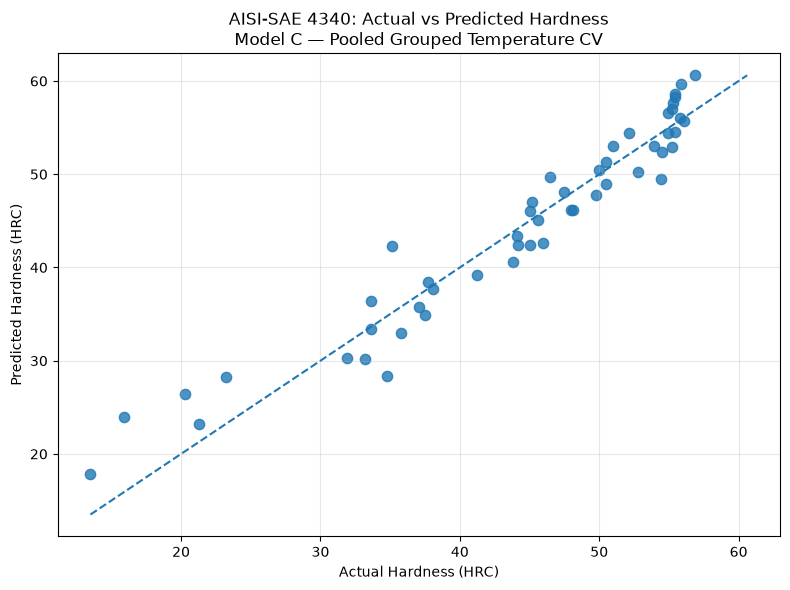

In [74]:
# ==========================================
# STEP 40B — ACTUAL VS PREDICTED
# MODEL C — POOLED GROUPED CV
# ==========================================

import matplotlib.pyplot as plt


actual = diagnostics_C[
    "Final hardness (HRC) - post tempering"
]

predicted = diagnostics_C[
    "Predicted hardness (HRC)"
]


plt.figure(figsize=(8, 6))

plt.scatter(
    actual,
    predicted,
    s=55,
    alpha=0.8
)


# Perfect prediction line
min_value = min(actual.min(), predicted.min())
max_value = max(actual.max(), predicted.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)


plt.xlabel("Actual Hardness (HRC)")
plt.ylabel("Predicted Hardness (HRC)")

plt.title(
    "AISI-SAE 4340: Actual vs Predicted Hardness\n"
    "Model C — Pooled Grouped Temperature CV"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

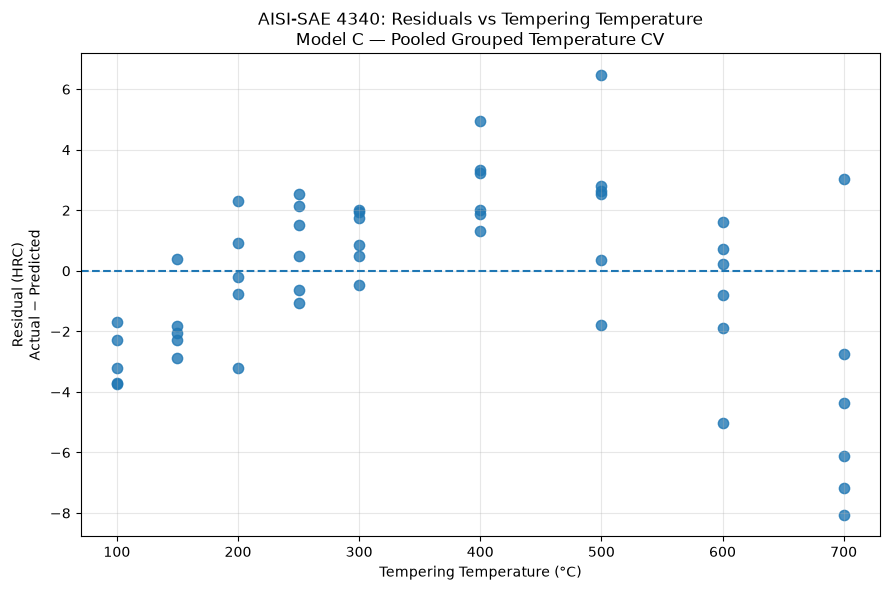

In [77]:
# ==========================================
# STEP 40C — RESIDUALS VS TEMPERATURE
# MODEL C — POOLED GROUPED CV
# ==========================================

import matplotlib.pyplot as plt


temperature = diagnostics_C[
    "Tempering temperature (ºC)"
]

residual = diagnostics_C[
    "Residual (HRC)"
]


plt.figure(figsize=(9, 6))

plt.scatter(
    temperature,
    residual,
    s=55,
    alpha=0.8
)


# Zero-error reference line
plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Residual (HRC)\nActual − Predicted")

plt.title(
    "AISI-SAE 4340: Residuals vs Tempering Temperature\n"
    "Model C — Pooled Grouped Temperature CV"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [78]:
# ==========================================
# STEP 40D — RESIDUAL SUMMARY BY TEMPERATURE
# MODEL C — POOLED GROUPED CV
# ==========================================

residual_by_temperature = (
    diagnostics_C
    .groupby("Tempering temperature (ºC)")
    .agg(
        Samples=("Residual (HRC)", "count"),
        Mean_Residual_HRC=("Residual (HRC)", "mean"),
        Mean_Absolute_Error_HRC=("Absolute error (HRC)", "mean"),
        Maximum_Absolute_Error_HRC=("Absolute error (HRC)", "max")
    )
    .reset_index()
)


print("=" * 75)
print("MODEL C — RESIDUAL SUMMARY BY TEMPERING TEMPERATURE")
print("=" * 75)

residual_by_temperature

MODEL C — RESIDUAL SUMMARY BY TEMPERING TEMPERATURE


,Tempering temperature (ºC),Samples,Mean_Residual_HRC,Mean_Absolute_Error_HRC,Maximum_Absolute_Error_HRC
0,100.0,5,-2.928648,2.928648,3.736504
1,150.0,5,-1.731416,1.891874,2.892148
2,200.0,5,-0.191080,1.485064,3.198754
3,250.0,6,0.837694,1.397811,2.548379
4,300.0,6,1.099227,1.256466,2.016884
5,400.0,6,2.794337,2.794337,4.960965
6,500.0,6,2.169554,2.763477,6.459037
7,600.0,6,-0.859262,1.716729,5.036298
8,700.0,6,-4.235083,5.250663,8.049282


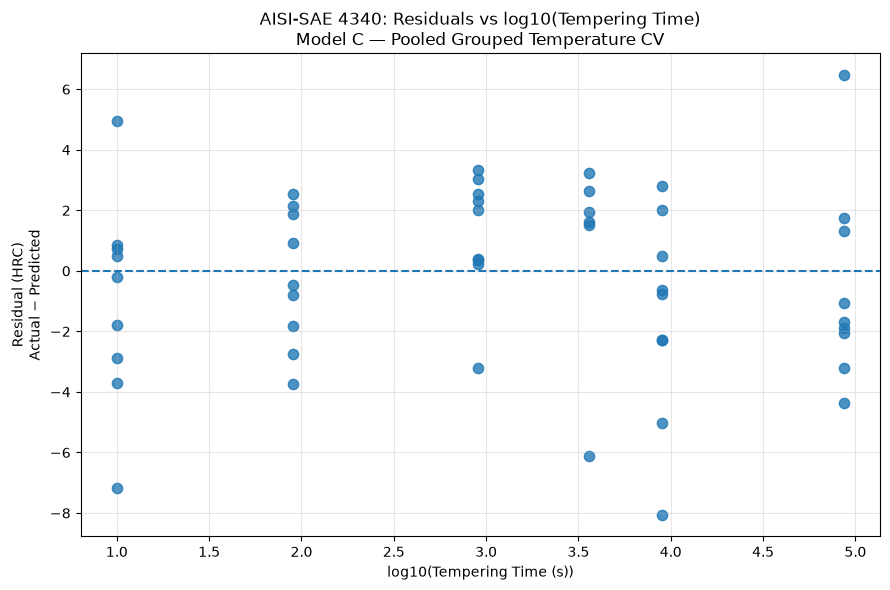

In [79]:
# ==========================================
# STEP 40E — RESIDUALS VS LOG10(TIME)
# MODEL C — POOLED GROUPED CV
# ==========================================

import matplotlib.pyplot as plt


log_time = diagnostics_C["log10_time"]

residual = diagnostics_C["Residual (HRC)"]


plt.figure(figsize=(9, 6))

plt.scatter(
    log_time,
    residual,
    s=55,
    alpha=0.8
)


# Zero-error reference line
plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel("log10(Tempering Time (s))")
plt.ylabel("Residual (HRC)\nActual − Predicted")

plt.title(
    "AISI-SAE 4340: Residuals vs log10(Tempering Time)\n"
    "Model C — Pooled Grouped Temperature CV"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [80]:
# ==========================================
# STEP 40F — LARGEST MODEL C ERRORS
# ==========================================

largest_errors_C = (
    diagnostics_C[
        [
            "Tempering temperature (ºC)",
            "Tempering time (s)",
            "Tempering time (h)",
            "Final hardness (HRC) - post tempering",
            "Predicted hardness (HRC)",
            "Residual (HRC)",
            "Absolute error (HRC)"
        ]
    ]
    .sort_values(
        "Absolute error (HRC)",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 75)
print("MODEL C — LARGEST POOLED GROUPED-CV PREDICTION ERRORS")
print("=" * 75)

largest_errors_C.head(10)

MODEL C — LARGEST POOLED GROUPED-CV PREDICTION ERRORS


,Tempering temperature (ºC),Tempering time (s),Tempering time (h),Final hardness (HRC) - post tempering,Predicted hardness (HRC),Residual (HRC),Absolute error (HRC)
0,700.0,9000,2.500000,15.9,23.949282,-8.049282,8.049282
1,700.0,10,0.002778,35.1,42.277334,-7.177334,7.177334
2,500.0,86400,24.000000,34.8,28.340963,6.459037,6.459037
3,700.0,3600,1.000000,20.3,26.418093,-6.118093,6.118093
4,600.0,9000,2.500000,23.2,28.236298,-5.036298,5.036298
5,400.0,10,0.002778,54.4,49.439035,4.960965,4.960965
6,700.0,86400,24.000000,13.5,17.855295,-4.355295,4.355295
7,100.0,90,0.025000,55.9,59.636504,-3.736504,3.736504
8,100.0,10,0.002778,56.9,60.611860,-3.711860,3.711860
9,400.0,900,0.250000,46.0,42.653622,3.346378,3.346378


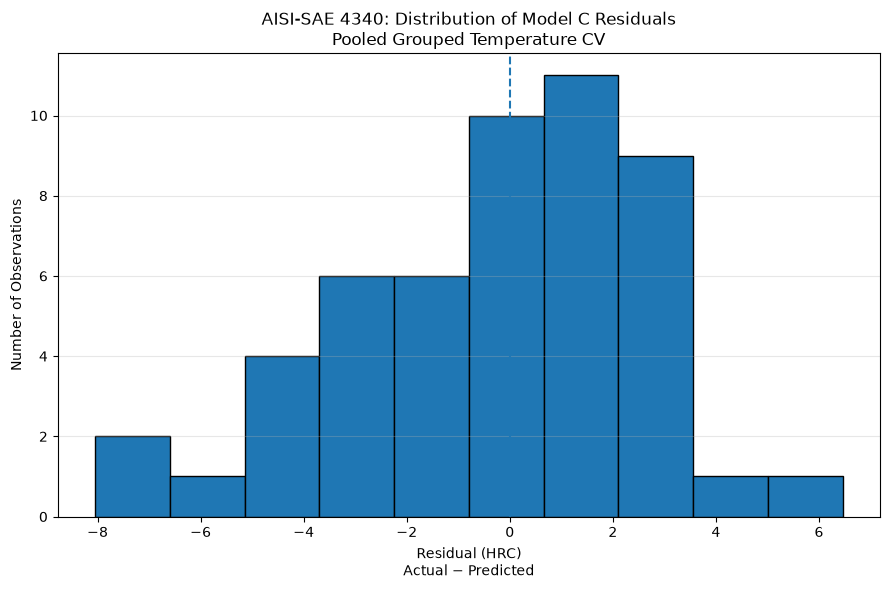

In [81]:
# ==========================================
# STEP 41 — MODEL C RESIDUAL DISTRIBUTION
# POOLED GROUPED CV
# ==========================================

import matplotlib.pyplot as plt


residual = diagnostics_C["Residual (HRC)"]


plt.figure(figsize=(9, 6))

plt.hist(
    residual,
    bins=10,
    edgecolor="black"
)


plt.axvline(
    0,
    linestyle="--"
)


plt.xlabel("Residual (HRC)\nActual − Predicted")
plt.ylabel("Number of Observations")

plt.title(
    "AISI-SAE 4340: Distribution of Model C Residuals\n"
    "Pooled Grouped Temperature CV"
)

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

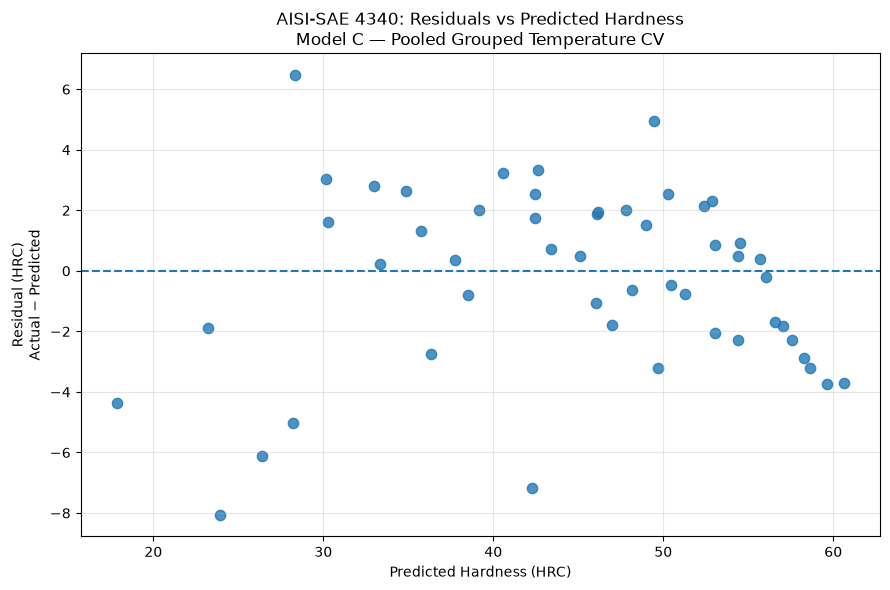

In [82]:
# ==========================================
# STEP 42 — RESIDUALS VS PREDICTED HARDNESS
# MODEL C — POOLED GROUPED CV
# ==========================================

import matplotlib.pyplot as plt


predicted = diagnostics_C[
    "Predicted hardness (HRC)"
]

residual = diagnostics_C[
    "Residual (HRC)"
]


plt.figure(figsize=(9, 6))

plt.scatter(
    predicted,
    residual,
    s=55,
    alpha=0.8
)


# Zero-error reference line
plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel("Predicted Hardness (HRC)")
plt.ylabel("Residual (HRC)\nActual − Predicted")

plt.title(
    "AISI-SAE 4340: Residuals vs Predicted Hardness\n"
    "Model C — Pooled Grouped Temperature CV"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [83]:
# ==========================================
# STEP 43A — MODEL C EFFECT SLOPES
# ==========================================

temperature_coefficient = -0.021445
log_time_coefficient = 0.041507
interaction_coefficient = -0.009068


# Representative tempering times
representative_times = [10, 900, 3600, 9000, 86400]

# Representative temperatures
representative_temperatures = [100, 300, 500, 700]


print("=" * 75)
print("MODEL C — MARGINAL EFFECTS")
print("=" * 75)


print("\nEFFECT OF TEMPERATURE")
print("-" * 75)

for time in representative_times:

    log_time = np.log10(time)

    temperature_effect = (
        temperature_coefficient
        + interaction_coefficient * log_time
    )

    print(
        f"At {time:>6} s "
        f"(log10(t)={log_time:.3f}): "
        f"dHRC/dT = {temperature_effect:.5f} HRC/°C"
    )


print("\nEFFECT OF LOG10(TIME)")
print("-" * 75)

for temperature in representative_temperatures:

    time_effect = (
        log_time_coefficient
        + interaction_coefficient * temperature
    )

    print(
        f"At {temperature:>3} °C: "
        f"dHRC/dlog10(t) = {time_effect:.5f} HRC"
    )

MODEL C — MARGINAL EFFECTS

EFFECT OF TEMPERATURE
---------------------------------------------------------------------------
At     10 s (log10(t)=1.000): dHRC/dT = -0.03051 HRC/°C
At    900 s (log10(t)=2.954): dHRC/dT = -0.04823 HRC/°C
At   3600 s (log10(t)=3.556): dHRC/dT = -0.05369 HRC/°C
At   9000 s (log10(t)=3.954): dHRC/dT = -0.05730 HRC/°C
At  86400 s (log10(t)=4.937): dHRC/dT = -0.06621 HRC/°C

EFFECT OF LOG10(TIME)
---------------------------------------------------------------------------
At 100 °C: dHRC/dlog10(t) = -0.86529 HRC
At 300 °C: dHRC/dlog10(t) = -2.67889 HRC
At 500 °C: dHRC/dlog10(t) = -4.49249 HRC
At 700 °C: dHRC/dlog10(t) = -6.30609 HRC


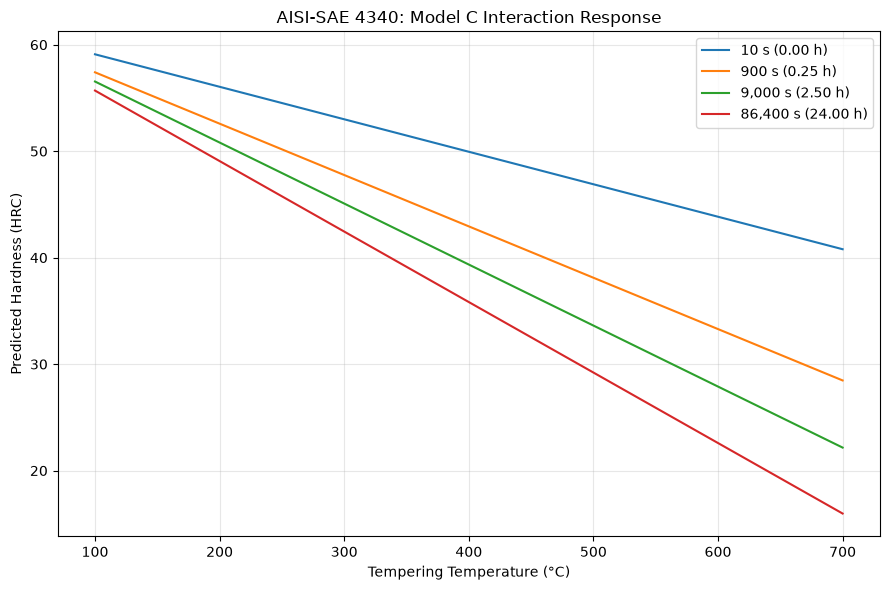

In [84]:
# ==========================================
# STEP 43B — MODEL C INTERACTION RESPONSE
# ==========================================

import numpy as np
import matplotlib.pyplot as plt


# Model C coefficients
intercept_C = 62.109275
temp_coef_C = -0.021445
log_time_coef_C = 0.041507
interaction_coef_C = -0.009068


# Temperature range
temperature_range = np.linspace(
    100,
    700,
    200
)


# Representative tempering times
representative_times = [
    10,
    900,
    9000,
    86400
]


plt.figure(figsize=(9, 6))


for time in representative_times:

    log_time = np.log10(time)

    predicted_hardness = (
        intercept_C
        + temp_coef_C * temperature_range
        + log_time_coef_C * log_time
        + interaction_coef_C
        * temperature_range
        * log_time
    )

    plt.plot(
        temperature_range,
        predicted_hardness,
        label=f"{time:,} s ({time/3600:.2f} h)"
    )


plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Predicted Hardness (HRC)")

plt.title(
    "AISI-SAE 4340: Model C Interaction Response"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

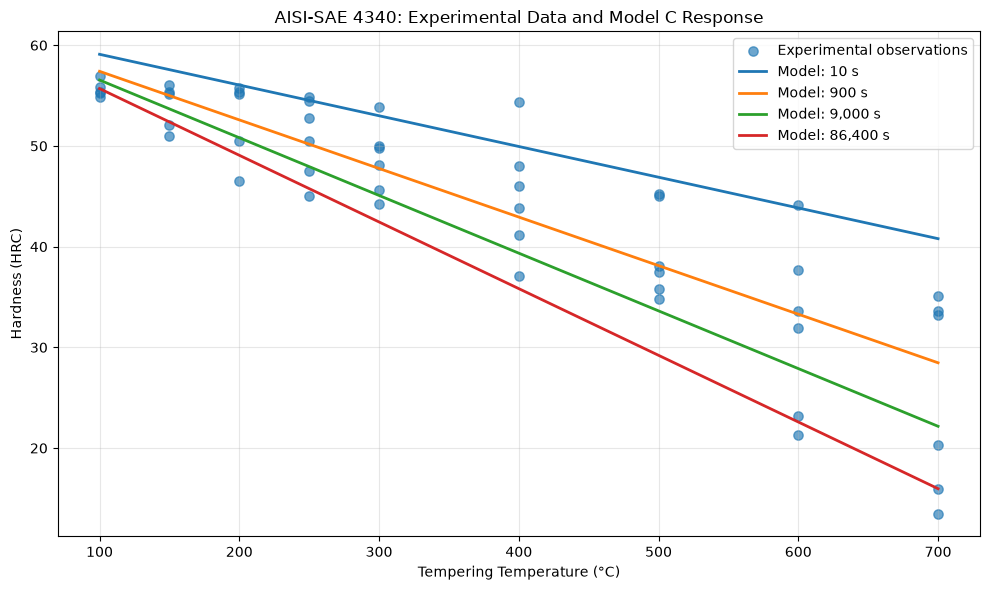

In [85]:
# ==========================================
# STEP 44 — EXPERIMENTAL DATA + MODEL C
# RESPONSE CURVES
# ==========================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------
# Model C coefficients
# ------------------------------------------

intercept_C = 62.109275
temp_coef_C = -0.021445
log_time_coef_C = 0.041507
interaction_coef_C = -0.009068


# ------------------------------------------
# Experimental data
# ------------------------------------------

experimental_temperature = df[
    "Tempering temperature (ºC)"
]

experimental_hardness = df[
    "Final hardness (HRC) - post tempering"
]


# ------------------------------------------
# Temperature range for model curves
# ------------------------------------------

temperature_range = np.linspace(
    100,
    700,
    200
)


# Representative times
representative_times = [
    10,
    900,
    9000,
    86400
]


plt.figure(figsize=(10, 6))


# ------------------------------------------
# Experimental observations
# ------------------------------------------

plt.scatter(
    experimental_temperature,
    experimental_hardness,
    s=45,
    alpha=0.65,
    label="Experimental observations"
)


# ------------------------------------------
# Model response curves
# ------------------------------------------

for time in representative_times:

    log_time = np.log10(time)

    predicted_hardness = (
        intercept_C
        + temp_coef_C * temperature_range
        + log_time_coef_C * log_time
        + interaction_coef_C
        * temperature_range
        * log_time
    )

    plt.plot(
        temperature_range,
        predicted_hardness,
        linewidth=2,
        label=f"Model: {time:,} s"
    )


plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Hardness (HRC)")

plt.title(
    "AISI-SAE 4340: Experimental Data and Model C Response"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [86]:
# ==========================================
# STEP 45 — FINAL MODEL C PREDICTION TABLE
# ==========================================

final_predictions_C = diagnostics_C[
    [
        "Tempering temperature (ºC)",
        "Tempering time (s)",
        "Tempering time (h)",
        "log10_time",
        "Final hardness (HRC) - post tempering",
        "Predicted hardness (HRC)",
        "Residual (HRC)",
        "Absolute error (HRC)"
    ]
].copy()


# Rename columns for a cleaner final dataset
final_predictions_C = final_predictions_C.rename(
    columns={
        "Tempering temperature (ºC)": "Temperature (ºC)",
        "Tempering time (s)": "Time (s)",
        "Tempering time (h)": "Time (h)",
        "log10_time": "log10(Time)",
        "Final hardness (HRC) - post tempering": "Actual Hardness (HRC)",
        "Predicted hardness (HRC)": "Predicted Hardness (HRC)"
    }
)


# Round numerical values
final_predictions_C = final_predictions_C.round(
    {
        "Temperature (ºC)": 1,
        "Time (s)": 0,
        "Time (h)": 6,
        "log10(Time)": 6,
        "Actual Hardness (HRC)": 3,
        "Predicted Hardness (HRC)": 3,
        "Residual (HRC)": 3,
        "Absolute error (HRC)": 3
    }
)


print("=" * 75)
print("FINAL MODEL C — POOLED GROUPED-CV PREDICTIONS")
print("=" * 75)

print("\nNumber of observations:", len(final_predictions_C))

final_predictions_C

FINAL MODEL C — POOLED GROUPED-CV PREDICTIONS

Number of observations: 51


,Temperature (ºC),Time (s),Time (h),log10(Time),Actual Hardness (HRC),Predicted Hardness (HRC),Residual (HRC),Absolute error (HRC)
0,100.0,10,0.002778,1.000000,56.9,60.612,-3.712,3.712
1,100.0,90,0.025000,1.954243,55.9,59.637,-3.737,3.737
2,100.0,900,0.250000,2.954243,55.4,58.614,-3.214,3.214
3,100.0,9000,2.500000,3.954243,55.3,57.592,-2.292,2.292
4,100.0,86400,24.000000,4.936514,54.9,56.588,-1.688,1.688
5,150.0,10,0.002778,1.000000,55.4,58.292,-2.892,2.892
6,150.0,90,0.025000,1.954243,55.2,57.026,-1.826,1.826
7,150.0,900,0.250000,2.954243,56.1,55.699,0.401,0.401
8,150.0,9000,2.500000,3.954243,52.1,54.372,-2.272,2.272
9,150.0,86400,24.000000,4.936514,51.0,53.068,-2.068,2.068


In [87]:
# ==========================================
# STEP 46 — EXPORT FINAL PROJECT RESULTS
# ==========================================

from pathlib import Path


# Create results directory
results_dir = Path("data/results")
results_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------
# 1. Final Model C predictions
# ------------------------------------------

final_predictions_C.to_csv(
    results_dir / "model_C_grouped_CV_predictions.csv",
    index=False
)


# ------------------------------------------
# 2. Final model comparison
# ------------------------------------------

final_model_comparison.to_csv(
    results_dir / "model_comparison.csv",
    index=False
)


# ------------------------------------------
# 3. Residual summary by temperature
# ------------------------------------------

residual_by_temperature.to_csv(
    results_dir / "model_C_residuals_by_temperature.csv",
    index=False
)


# ------------------------------------------
# 4. Largest prediction errors
# ------------------------------------------

largest_errors_C.to_csv(
    results_dir / "model_C_largest_errors.csv",
    index=False
)


print("=" * 70)
print("FINAL RESULTS EXPORTED")
print("=" * 70)

print("\nSaved files:")

print(
    results_dir /
    "model_C_grouped_CV_predictions.csv"
)

print(
    results_dir /
    "model_comparison.csv"
)

print(
    results_dir /
    "model_C_residuals_by_temperature.csv"
)

print(
    results_dir /
    "model_C_largest_errors.csv"
)

FINAL RESULTS EXPORTED

Saved files:
data\results\model_C_grouped_CV_predictions.csv
data\results\model_comparison.csv
data\results\model_C_residuals_by_temperature.csv
data\results\model_C_largest_errors.csv


In [88]:
# ==========================================
# STEP 47 — FINAL MODEL SUMMARY
# ==========================================

# Model C final equation
model_C_summary = {
    "Model": "Model C — Interaction Linear Regression",
    "Features": "Temperature + log10(Time) + Temperature × log10(Time)",
    "Intercept": 62.109275,
    "Temperature coefficient": -0.021445,
    "log10(Time) coefficient": 0.041507,
    "Interaction coefficient": -0.009068,
    "Random Test MAE (HRC)": mae_C,
    "Random Test RMSE (HRC)": rmse_C,
    "Random Test R²": r2_C,
    "Grouped CV MAE (HRC)": pooled_mae_C,
    "Grouped CV RMSE (HRC)": pooled_rmse_C,
    "Grouped CV R²": pooled_r2_C
}


final_summary = pd.DataFrame(
    [model_C_summary]
)


print("=" * 75)
print("FINAL SELECTED MODEL — MODEL C")
print("=" * 75)

print("\nModel:")
print(model_C_summary["Model"])

print("\nFeatures:")
print(model_C_summary["Features"])

print("\nRegression equation:")
print(
    "HRC = 62.109275 "
    "- 0.021445 × Temperature "
    "+ 0.041507 × log10(Time) "
    "- 0.009068 × Temperature × log10(Time)"
)

print("\nRandom 80/20 Test:")
print(
    f"MAE  : {mae_C:.3f} HRC"
)
print(
    f"RMSE : {rmse_C:.3f} HRC"
)
print(
    f"R²   : {r2_C:.3f}"
)

print("\nPooled Grouped-Temperature CV:")
print(
    f"MAE  : {pooled_mae_C:.3f} HRC"
)
print(
    f"RMSE : {pooled_rmse_C:.3f} HRC"
)
print(
    f"R²   : {pooled_r2_C:.3f}"
)

print("\nFinal summary table:")
final_summary

FINAL SELECTED MODEL — MODEL C

Model:
Model C — Interaction Linear Regression

Features:
Temperature + log10(Time) + Temperature × log10(Time)

Regression equation:
HRC = 62.109275 - 0.021445 × Temperature + 0.041507 × log10(Time) - 0.009068 × Temperature × log10(Time)

Random 80/20 Test:
MAE  : 1.977 HRC
RMSE : 2.291 HRC
R²   : 0.944

Pooled Grouped-Temperature CV:
MAE  : 2.404 HRC
RMSE : 2.990 HRC
R²   : 0.929

Final summary table:


,Model,Features,Intercept,Temperature coefficient,log10(Time) coefficient,Interaction coefficient,Random Test MAE (HRC),Random Test RMSE (HRC),Random Test R²,Grouped CV MAE (HRC),Grouped CV RMSE (HRC),Grouped CV R²
0,Model C — Interaction Linear Regression,Temperature + log10(Time) + Temperature × log1...,62.109275,-0.021445,0.041507,-0.009068,1.976644,2.290535,0.943578,2.404016,2.990258,0.929097


In [89]:
# ==========================================
# STEP 48 — EXPORT FINAL MODEL SUMMARY
# ==========================================

final_summary.to_csv(
    results_dir / "final_model_summary.csv",
    index=False
)

print("=" * 70)
print("FINAL MODEL SUMMARY SAVED")
print("=" * 70)

print(
    results_dir / "final_model_summary.csv"
)

FINAL MODEL SUMMARY SAVED
data\results\final_model_summary.csv


In [90]:
# ==========================================
# STEP 49A — CREATE FIGURES DIRECTORY
# ==========================================

from pathlib import Path

figures_dir = Path("figures")

figures_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("FIGURES DIRECTORY READY")
print("=" * 70)

print("Location:", figures_dir)

FIGURES DIRECTORY READY
Location: figures


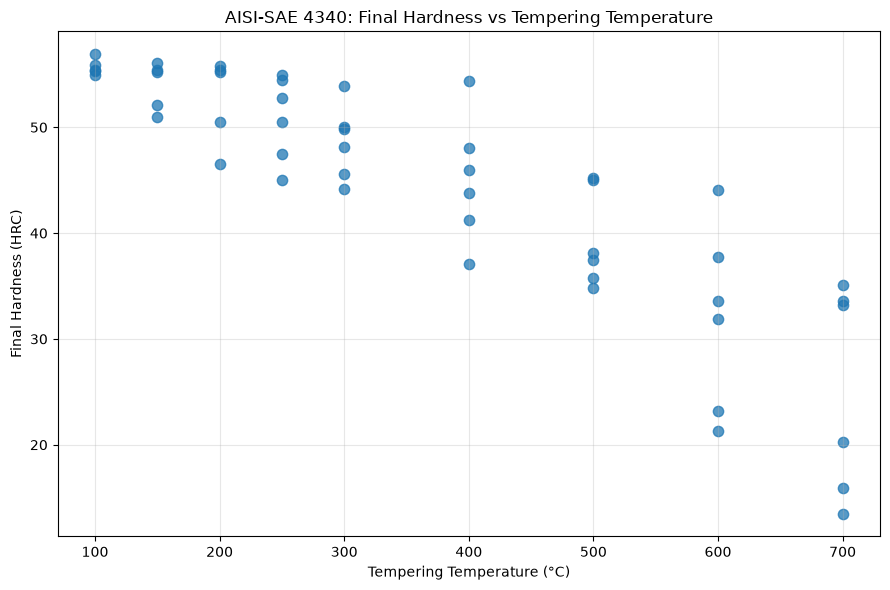

FIGURE 1 SAVED
figures\01_hardness_vs_temperature.png


In [91]:
# ==========================================
# STEP 49B — FINAL FIGURE 1
# HARDNESS VS TEMPERING TEMPERATURE
# ==========================================

import matplotlib.pyplot as plt


temperature = df["Tempering temperature (ºC)"]
hardness = df["Final hardness (HRC) - post tempering"]


plt.figure(figsize=(9, 6))

plt.scatter(
    temperature,
    hardness,
    s=55,
    alpha=0.75
)


plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Final Hardness (HRC)")

plt.title(
    "AISI-SAE 4340: Final Hardness vs Tempering Temperature"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# Save high-resolution figure
plt.savefig(
    figures_dir / "01_hardness_vs_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("FIGURE 1 SAVED")
print("=" * 70)

print(
    figures_dir /
    "01_hardness_vs_temperature.png"
)

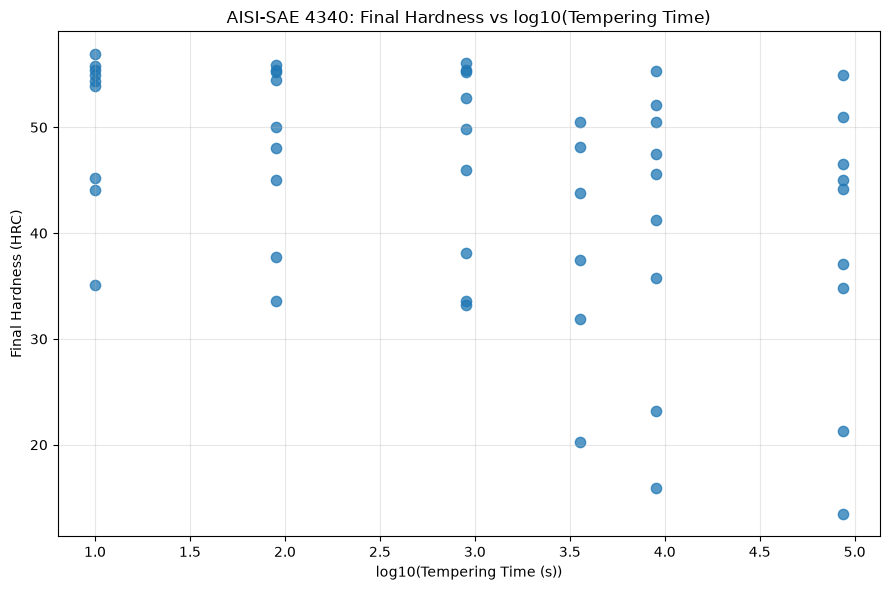

FIGURE 2 SAVED
figures\02_hardness_vs_log_time.png


In [92]:
# ==========================================
# STEP 49C — FINAL FIGURE 2
# HARDNESS VS LOG10(TEMPERING TIME)
# ==========================================

import matplotlib.pyplot as plt


log_time = np.log10(
    df["Tempering time (s)"]
)

hardness = df[
    "Final hardness (HRC) - post tempering"
]


plt.figure(figsize=(9, 6))

plt.scatter(
    log_time,
    hardness,
    s=55,
    alpha=0.75
)


plt.xlabel("log10(Tempering Time (s))")
plt.ylabel("Final Hardness (HRC)")

plt.title(
    "AISI-SAE 4340: Final Hardness vs log10(Tempering Time)"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    figures_dir / "02_hardness_vs_log_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("FIGURE 2 SAVED")
print("=" * 70)

print(
    figures_dir /
    "02_hardness_vs_log_time.png"
)

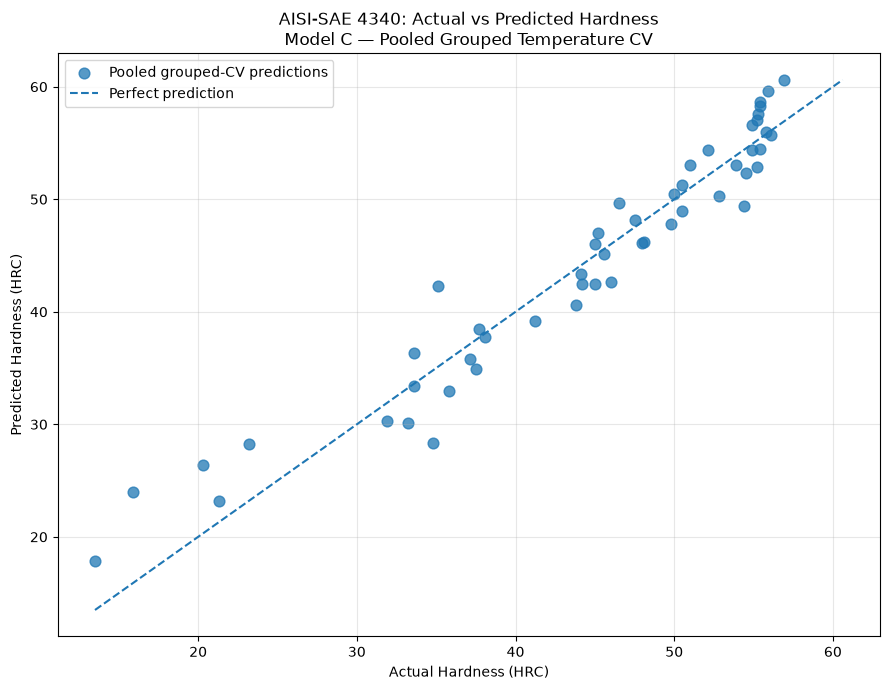

FIGURE 3 SAVED
figures\03_actual_vs_predicted_model_C.png


In [93]:
# ==========================================
# STEP 49D — FINAL FIGURE 3
# ACTUAL VS PREDICTED HARDNESS
# MODEL C — POOLED GROUPED CV
# ==========================================

import matplotlib.pyplot as plt


actual = diagnostics_C[
    "Final hardness (HRC) - post tempering"
]

predicted = diagnostics_C[
    "Predicted hardness (HRC)"
]


plt.figure(figsize=(9, 7))

plt.scatter(
    actual,
    predicted,
    s=60,
    alpha=0.75,
    label="Pooled grouped-CV predictions"
)


# ------------------------------------------
# Perfect prediction line
# ------------------------------------------

min_value = min(
    actual.min(),
    predicted.min()
)

max_value = max(
    actual.max(),
    predicted.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)


plt.xlabel("Actual Hardness (HRC)")
plt.ylabel("Predicted Hardness (HRC)")

plt.title(
    "AISI-SAE 4340: Actual vs Predicted Hardness\n"
    "Model C — Pooled Grouped Temperature CV"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    figures_dir / "03_actual_vs_predicted_model_C.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("FIGURE 3 SAVED")
print("=" * 70)

print(
    figures_dir /
    "03_actual_vs_predicted_model_C.png"
)

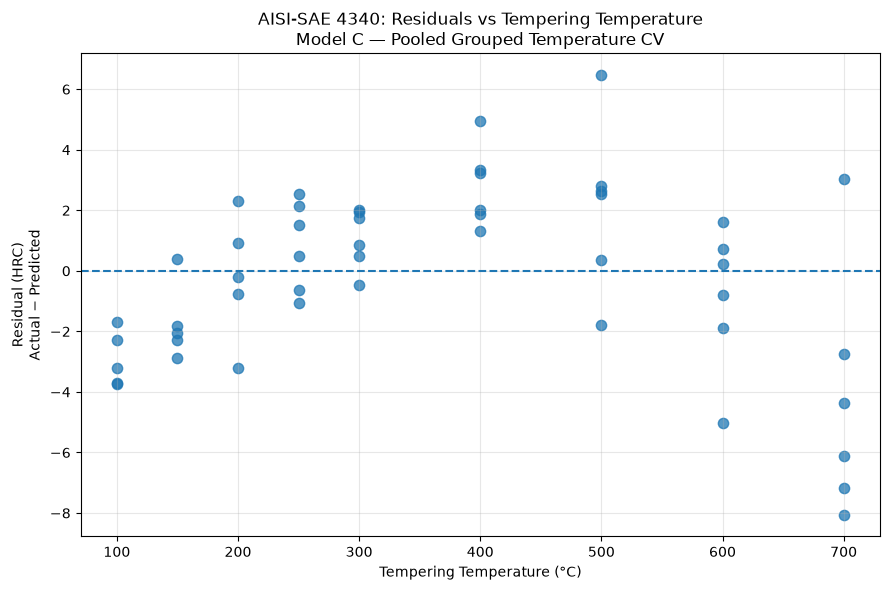

FIGURE 4 SAVED
figures\04_residuals_vs_temperature_model_C.png


In [94]:
# ==========================================
# STEP 49E — FINAL FIGURE 4
# RESIDUALS VS TEMPERING TEMPERATURE
# MODEL C — POOLED GROUPED CV
# ==========================================

import matplotlib.pyplot as plt


temperature = diagnostics_C[
    "Tempering temperature (ºC)"
]

residual = diagnostics_C[
    "Residual (HRC)"
]


plt.figure(figsize=(9, 6))

plt.scatter(
    temperature,
    residual,
    s=55,
    alpha=0.75
)


# Zero-error reference
plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Residual (HRC)\nActual − Predicted")

plt.title(
    "AISI-SAE 4340: Residuals vs Tempering Temperature\n"
    "Model C — Pooled Grouped Temperature CV"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    figures_dir / "04_residuals_vs_temperature_model_C.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("FIGURE 4 SAVED")
print("=" * 70)

print(
    figures_dir /
    "04_residuals_vs_temperature_model_C.png"
)

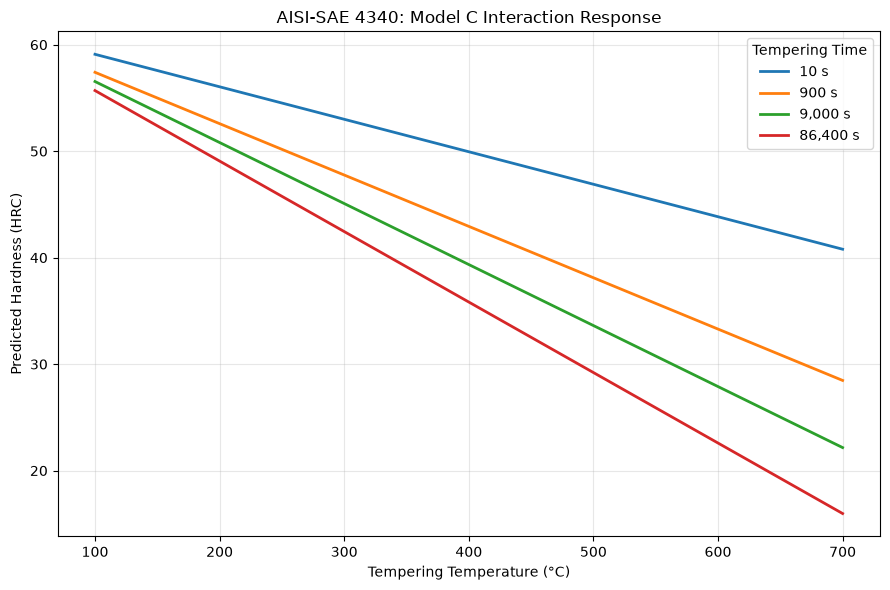

FIGURE 5 SAVED
figures\05_model_C_interaction_response.png


In [95]:
# ==========================================
# STEP 49F — FINAL FIGURE 5
# MODEL C INTERACTION RESPONSE
# ==========================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------
# Model C coefficients
# ------------------------------------------

intercept_C = 62.109275
temp_coef_C = -0.021445
log_time_coef_C = 0.041507
interaction_coef_C = -0.009068


# ------------------------------------------
# Temperature range
# ------------------------------------------

temperature_range = np.linspace(
    100,
    700,
    200
)


# Representative experimental times
representative_times = [
    10,
    900,
    9000,
    86400
]


plt.figure(figsize=(9, 6))


for time in representative_times:

    log_time = np.log10(time)

    predicted_hardness = (
        intercept_C
        + temp_coef_C * temperature_range
        + log_time_coef_C * log_time
        + interaction_coef_C
        * temperature_range
        * log_time
    )

    plt.plot(
        temperature_range,
        predicted_hardness,
        linewidth=2,
        label=f"{time:,} s"
    )


plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Predicted Hardness (HRC)")

plt.title(
    "AISI-SAE 4340: Model C Interaction Response"
)

plt.legend(
    title="Tempering Time"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    figures_dir / "05_model_C_interaction_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("FIGURE 5 SAVED")
print("=" * 70)

print(
    figures_dir /
    "05_model_C_interaction_response.png"
)

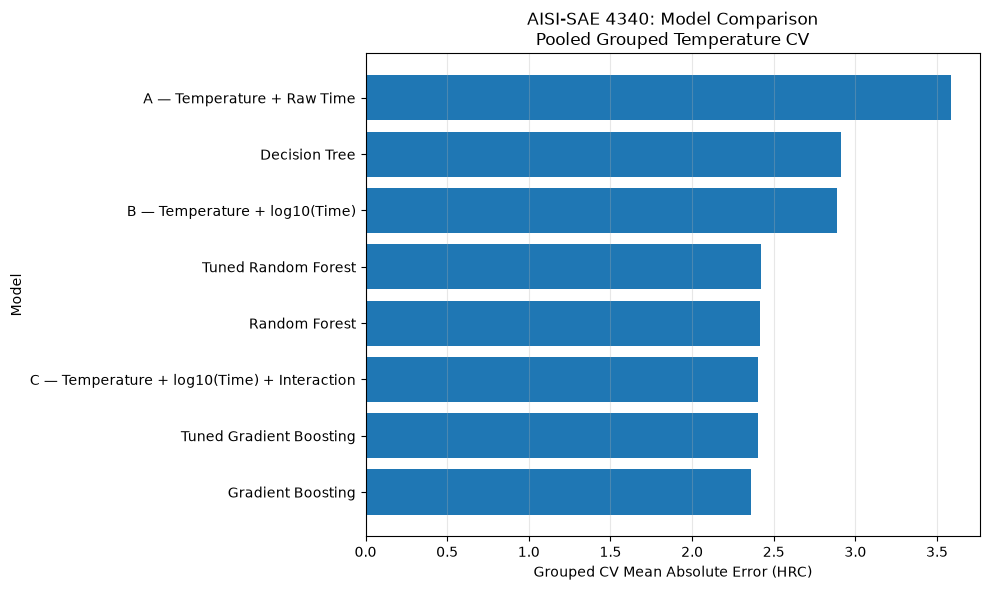

FIGURE 6 SAVED
figures\06_model_comparison_grouped_CV.png


In [96]:
# ==========================================
# STEP 50 — FINAL MODEL COMPARISON FIGURE
# GROUPED TEMPERATURE CV
# ==========================================

import matplotlib.pyplot as plt


# ------------------------------------------
# Prepare comparison data
# ------------------------------------------

comparison_plot = final_model_comparison[
    [
        "Model",
        "Grouped MAE (HRC)"
    ]
].copy()


comparison_plot = comparison_plot.sort_values(
    "Grouped MAE (HRC)",
    ascending=True
)


# ------------------------------------------
# Create figure
# ------------------------------------------

plt.figure(figsize=(10, 6))


plt.barh(
    comparison_plot["Model"],
    comparison_plot["Grouped MAE (HRC)"]
)


plt.xlabel("Grouped CV Mean Absolute Error (HRC)")
plt.ylabel("Model")

plt.title(
    "AISI-SAE 4340: Model Comparison\n"
    "Pooled Grouped Temperature CV"
)

plt.grid(
    True,
    axis="x",
    alpha=0.3
)

plt.tight_layout()


# ------------------------------------------
# Save figure
# ------------------------------------------

plt.savefig(
    figures_dir / "06_model_comparison_grouped_CV.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("FIGURE 6 SAVED")
print("=" * 70)

print(
    figures_dir /
    "06_model_comparison_grouped_CV.png"
)

In [97]:
# ==========================================
# STEP 51 — FINAL MODEL COMPARISON TABLE
# ==========================================

final_results_table = final_model_comparison[
    [
        "Model",
        "Random MAE (HRC)",
        "Random RMSE (HRC)",
        "Random R²",
        "Grouped MAE (HRC)",
        "Grouped RMSE (HRC)",
        "Grouped R²"
    ]
].copy()


# Round metrics
metric_columns = [
    "Random MAE (HRC)",
    "Random RMSE (HRC)",
    "Random R²",
    "Grouped MAE (HRC)",
    "Grouped RMSE (HRC)",
    "Grouped R²"
]

final_results_table[metric_columns] = (
    final_results_table[metric_columns]
    .round(3)
)


# Rank models by grouped MAE
final_results_table["Grouped MAE Rank"] = (
    final_results_table["Grouped MAE (HRC)"]
    .rank(method="min")
    .astype(int)
)


final_results_table = (
    final_results_table
    .sort_values("Grouped MAE Rank")
    .reset_index(drop=True)
)


print("=" * 80)
print("FINAL MODEL COMPARISON — ALL VALIDATION METRICS")
print("=" * 80)

final_results_table

FINAL MODEL COMPARISON — ALL VALIDATION METRICS


,Model,Random MAE (HRC),Random RMSE (HRC),Random R²,Grouped MAE (HRC),Grouped RMSE (HRC),Grouped R²,Grouped MAE Rank
0,Gradient Boosting,2.572,3.590,0.861,2.364,3.605,0.897,1
1,Tuned Gradient Boosting,2.468,3.408,0.875,2.403,3.615,0.896,2
2,C — Temperature + log10(Time) + Interaction,1.977,2.291,0.944,2.404,2.990,0.929,3
3,Random Forest,2.318,3.018,0.902,2.419,3.754,0.888,4
4,Tuned Random Forest,2.336,3.028,0.901,2.423,3.754,0.888,5
5,B — Temperature + log10(Time),2.363,2.809,0.915,2.889,3.978,0.875,6
6,Decision Tree,2.664,3.665,0.856,2.914,4.275,0.855,7
7,A — Temperature + Raw Time,2.896,3.965,0.831,3.584,4.721,0.823,8


In [98]:
# ==========================================
# STEP 51B — SAVE FINAL RESULTS TABLE
# ==========================================

final_results_table.to_csv(
    results_dir / "final_model_comparison.csv",
    index=False
)

print("=" * 70)
print("FINAL MODEL COMPARISON SAVED")
print("=" * 70)

print(
    results_dir /
    "final_model_comparison.csv"
)

FINAL MODEL COMPARISON SAVED
data\results\final_model_comparison.csv


In [99]:
# ==========================================
# STEP 52A — VERIFY PROJECT OUTPUTS
# ==========================================

from pathlib import Path

project_root = Path.cwd()

print("=" * 70)
print("PROJECT ROOT")
print("=" * 70)
print(project_root)

print("\n" + "=" * 70)
print("RESULT FILES")
print("=" * 70)

results_dir = project_root / "data" / "results"

if results_dir.exists():
    for file in sorted(results_dir.iterdir()):
        print(file)
else:
    print("data/results directory not found")


print("\n" + "=" * 70)
print("FIGURE FILES")
print("=" * 70)

figures_dir = project_root / "figures"

if figures_dir.exists():
    for file in sorted(figures_dir.iterdir()):
        print(file)
else:
    print("figures directory not found")

PROJECT ROOT
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks

RESULT FILES
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\data\results\final_model_comparison.csv
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\data\results\final_model_summary.csv
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\data\results\model_C_grouped_CV_predictions.csv
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\data\results\model_C_largest_errors.csv
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\data\results\model_C_residuals_by_temperature.csv
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\data\results\model_comparison.csv

FIGURE FILES
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\figures\01_hardness_vs_temperature.png
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\figures\02_hardness_vs_log_time.png
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\figures\03_actual_vs_predicted_model_C.png
c:\Users\mians\Projects\Heat_Treatment_ML\notebooks\figures\04_residuals

In [100]:
# ==========================================
# STEP 52B — MOVE OUTPUTS TO PROJECT ROOT
# ==========================================

from pathlib import Path
import shutil


# Current location
notebooks_dir = Path.cwd()

# Actual project root
project_root = notebooks_dir.parent


# Current output folders
current_results = notebooks_dir / "data" / "results"
current_figures = notebooks_dir / "figures"


# Correct output folders
correct_results = project_root / "data" / "results"
correct_figures = project_root / "figures"


# Create correct directories
correct_results.mkdir(
    parents=True,
    exist_ok=True
)

correct_figures.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------
# Move result files
# ------------------------------------------

if current_results.exists():

    for file in current_results.iterdir():

        destination = correct_results / file.name

        shutil.move(
            str(file),
            str(destination)
        )


# ------------------------------------------
# Move figure files
# ------------------------------------------

if current_figures.exists():

    for file in current_figures.iterdir():

        destination = correct_figures / file.name

        shutil.move(
            str(file),
            str(destination)
        )


print("=" * 70)
print("OUTPUTS MOVED TO PROJECT ROOT")
print("=" * 70)

print("\nProject root:")
print(project_root)

print("\nResults:")
print(correct_results)

print("\nFigures:")
print(correct_figures)

OUTPUTS MOVED TO PROJECT ROOT

Project root:
c:\Users\mians\Projects\Heat_Treatment_ML

Results:
c:\Users\mians\Projects\Heat_Treatment_ML\data\results

Figures:
c:\Users\mians\Projects\Heat_Treatment_ML\figures


In [101]:
# ==========================================
# STEP 52C — PROJECT PATH CONFIGURATION
# ==========================================

from pathlib import Path


# Notebook is located inside:
# Heat_Treatment_ML/notebooks/

PROJECT_ROOT = Path.cwd().parent


DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"


# Make sure directories exist
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 70)
print("PROJECT PATHS CONFIGURED")
print("=" * 70)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nFigures directory:")
print(FIGURES_DIR)

PROJECT PATHS CONFIGURED

Project root:
c:\Users\mians\Projects\Heat_Treatment_ML

Results directory:
c:\Users\mians\Projects\Heat_Treatment_ML\data\results

Figures directory:
c:\Users\mians\Projects\Heat_Treatment_ML\figures


In [102]:
# ==========================================
# STEP 52D — PROJECT STRUCTURE CHECK
# ==========================================

from pathlib import Path


def show_tree(path, prefix=""):
    items = sorted(
        path.iterdir(),
        key=lambda x: (x.is_file(), x.name.lower())
    )

    for i, item in enumerate(items):

        connector = "└── " if i == len(items) - 1 else "├── "

        print(prefix + connector + item.name)

        if item.is_dir():
            extension = "    " if i == len(items) - 1 else "│   "
            show_tree(item, prefix + extension)


print("=" * 70)
print("HEAT TREATMENT ML — PROJECT STRUCTURE")
print("=" * 70)

print(PROJECT_ROOT)

show_tree(PROJECT_ROOT)

HEAT TREATMENT ML — PROJECT STRUCTURE
c:\Users\mians\Projects\Heat_Treatment_ML
├── .venv
│   ├── Include
│   ├── Lib
│   │   └── site-packages
│   │       ├── __pycache__
│   │       │   ├── ipykernel_launcher.cpython-314.pyc
│   │       │   ├── ipython_pygments_lexers.cpython-314.pyc
│   │       │   ├── jupyter.cpython-314.pyc
│   │       │   ├── nest_asyncio2.cpython-314.pyc
│   │       │   ├── pylab.cpython-314.pyc
│   │       │   ├── six.cpython-314.pyc
│   │       │   ├── threadpoolctl.cpython-314.pyc
│   │       │   └── typing_extensions.cpython-314.pyc
│   │       ├── asttokens
│   │       │   ├── __pycache__
│   │       │   │   ├── __init__.cpython-314.pyc
│   │       │   │   ├── astroid_compat.cpython-314.pyc
│   │       │   │   ├── asttokens.cpython-314.pyc
│   │       │   │   ├── line_numbers.cpython-314.pyc
│   │       │   │   ├── mark_tokens.cpython-314.pyc
│   │       │   │   ├── util.cpython-314.pyc
│   │       │   │   └── version.cpython-314.pyc
│   │       │   ├── __i

In [103]:
# ==========================================
# STEP 52E — CLEAN PROJECT STRUCTURE CHECK
# ==========================================

from pathlib import Path


EXCLUDED_DIRS = {
    ".venv",
    "__pycache__",
    ".git"
}


def show_clean_tree(path, prefix=""):
    
    items = [
        item for item in path.iterdir()
        if item.name not in EXCLUDED_DIRS
    ]

    items = sorted(
        items,
        key=lambda x: (x.is_file(), x.name.lower())
    )

    for i, item in enumerate(items):

        connector = (
            "└── "
            if i == len(items) - 1
            else "├── "
        )

        print(prefix + connector + item.name)

        if item.is_dir():

            extension = (
                "    "
                if i == len(items) - 1
                else "│   "
            )

            show_clean_tree(
                item,
                prefix + extension
            )


print("=" * 70)
print("CLEAN PROJECT STRUCTURE")
print("=" * 70)

print(PROJECT_ROOT)

show_clean_tree(PROJECT_ROOT)

CLEAN PROJECT STRUCTURE
c:\Users\mians\Projects\Heat_Treatment_ML
├── data
│   ├── processed
│   │   └── 4340_Penha2010_processed.csv
│   ├── raw
│   │   └── Tempering data for carbon and low alloy steels - Raiipa.csv
│   └── results
│       ├── final_model_comparison.csv
│       ├── final_model_summary.csv
│       ├── model_C_grouped_CV_predictions.csv
│       ├── model_C_largest_errors.csv
│       ├── model_C_residuals_by_temperature.csv
│       └── model_comparison.csv
├── figures
│   ├── 01_hardness_vs_temperature.png
│   ├── 02_hardness_vs_log_time.png
│   ├── 03_actual_vs_predicted_model_C.png
│   ├── 04_residuals_vs_temperature_model_C.png
│   ├── 05_model_C_interaction_response.png
│   └── 06_model_comparison_grouped_CV.png
├── notebooks
│   └── 4340_heat_treatment_ML.ipynb
└── src
    ├── 01_dataset_overview.py
    ├── 02_material_heat_treatment_summary.py
    ├── 03_4340_structure.py
    ├── 04_4340_source_analysis.py
    ├── 05_4340_heat_treatment_matrix.py
    ├── 06_4340_f

In [104]:
# ==========================================
# STEP 53 — CREATE REQUIREMENTS.TXT
# ==========================================

requirements = """numpy==2.5.3
pandas==3.0.5
matplotlib==3.11.2
scikit-learn==1.9.1
jupyter
ipykernel
"""

requirements_path = PROJECT_ROOT / "requirements.txt"

requirements_path.write_text(
    requirements,
    encoding="utf-8"
)

print("=" * 70)
print("REQUIREMENTS.TXT CREATED")
print("=" * 70)

print(requirements_path)

print("\nContents:")
print(requirements)

REQUIREMENTS.TXT CREATED
c:\Users\mians\Projects\Heat_Treatment_ML\requirements.txt

Contents:
numpy==2.5.3
pandas==3.0.5
matplotlib==3.11.2
scikit-learn==1.9.1
jupyter
ipykernel



In [105]:
# ==========================================
# STEP 54 — CREATE .GITIGNORE
# ==========================================

gitignore = """# Python
__pycache__/
*.py[cod]
*.pyo

# Virtual environment
.venv/
venv/
env/

# Jupyter
.ipynb_checkpoints/

# VS Code
.vscode/

# OS files
.DS_Store
Thumbs.db

# Python packaging
*.egg-info/
dist/
build/

# Temporary files
*.tmp
*.temp
"""

gitignore_path = PROJECT_ROOT / ".gitignore"

gitignore_path.write_text(
    gitignore,
    encoding="utf-8"
)

print("=" * 70)
print(".GITIGNORE CREATED")
print("=" * 70)

print(gitignore_path)

print("\nContents:")
print(gitignore)

.GITIGNORE CREATED
c:\Users\mians\Projects\Heat_Treatment_ML\.gitignore

Contents:
# Python
__pycache__/
*.py[cod]
*.pyo

# Virtual environment
.venv/
venv/
env/

# Jupyter
.ipynb_checkpoints/

# VS Code
.vscode/

# OS files
.DS_Store
Thumbs.db

# Python packaging
*.egg-info/
dist/
build/

# Temporary files
*.tmp
*.temp



In [109]:
# ==========================================
# STEP 55A — CREATE README.MD
# ==========================================

from pathlib import Path

readme_path = PROJECT_ROOT / "README.md"

readme_lines = [
    "# Heat Treatment ML — AISI-SAE 4340 Steel",
    "",
    "## Predicting Final Hardness from Tempering Temperature and Time",
    "",
    "A materials engineering and machine learning project investigating the relationship between **tempering temperature, tempering time, and final hardness of AISI-SAE 4340 steel**.",
    "",
    "The project combines heat-treatment metallurgy with supervised machine learning, feature engineering, model comparison, grouped cross-validation, residual diagnostics, and interpretable interaction modeling.",
    "",
    "---",
    "",
    "## Project Overview",
    "",
    "Tempering is a critical heat-treatment operation used to modify the mechanical properties of quenched steels.",
    "",
    "For AISI-SAE 4340 steel, final hardness depends strongly on both tempering temperature and tempering time.",
    "",
    "Because tempering time spans several orders of magnitude, this project investigates whether a logarithmic transformation of time provides a more suitable representation for hardness prediction.",
    "",
    "---",
    "",
    "## Objectives",
    "",
    "1. Extract and preprocess AISI-SAE 4340 experimental data.",
    "2. Investigate the relationship between tempering temperature, tempering time, and final hardness.",
    "3. Compare raw tempering time with `log10(time)`.",
    "4. Introduce a temperature–time interaction term.",
    "5. Compare linear regression, decision tree, random forest, and gradient boosting models.",
    "6. Evaluate models using random train-test splitting and grouped temperature cross-validation.",
    "7. Analyze residuals and temperature-dependent prediction errors.",
    "8. Identify an interpretable model suitable for materials-engineering analysis.",
    "",
    "---",
    "",
    "## Dataset",
    "",
    "The project uses experimental tempering data for carbon and low-alloy steels and extracts observations corresponding to **AISI-SAE 4340**.",
    "",
    "The extracted dataset contains **51 observations** distributed across tempering temperatures from **100°C to 700°C**.",
    "",
    "### Main Variables",
    "",
    "| Variable | Description |",
    "|---|---|",
    "| Tempering Temperature | Tempering temperature in °C |",
    "| Tempering Time | Tempering duration in seconds |",
    "| log10(Time) | Base-10 logarithm of tempering time |",
    "| Final Hardness | Final hardness after tempering in HRC |",
    "",
    "Processed data:",
    "`data/processed/4340_Penha2010_processed.csv`",
    "",
    "---",
    "",
    "## Feature Engineering",
    "",
    "Three feature representations were investigated.",
    "",
    "### Model A — Temperature + Raw Time",
    "",
    "- Temperature",
    "- Tempering Time",
    "",
    "### Model B — Temperature + Logarithmic Time",
    "",
    "- Temperature",
    "- `log10(Time)`",
    "",
    "### Model C — Temperature + Logarithmic Time + Interaction",
    "",
    "- Temperature",
    "- `log10(Time)`",
    "- Temperature × `log10(Time)`",
    "",
    "The interaction term allows the effect of temperature to vary with tempering time.",
    "",
    "---",
    "",
    "## Models Evaluated",
    "",
    "- Linear Regression — Model A",
    "- Linear Regression — Model B",
    "- Interaction Linear Regression — Model C",
    "- Decision Tree Regression",
    "- Random Forest Regression",
    "- Tuned Random Forest Regression",
    "- Gradient Boosting Regression",
    "- Tuned Gradient Boosting Regression",
    "",
    "---",
    "",
    "## Validation Strategy",
    "",
    "A random 80/20 train-test split was initially used for model development.",
    "",
    "However, random splitting can place observations from the same tempering temperature in both training and testing datasets.",
    "",
    "Because the objective is to assess performance on **unseen tempering temperatures**, the primary validation strategy used grouped temperature cross-validation.",
    "",
    "Each tempering temperature was treated as a group. The model was repeatedly trained using observations from several temperatures and evaluated on a completely held-out temperature.",
    "",
    "The out-of-fold predictions from all groups were pooled to calculate MAE, RMSE, and R².",
    "",
    "---",
    "",
    "# Results",
    "",
    "## Pooled Grouped-Temperature Cross-Validation",
    "",
    "| Model | MAE (HRC) | RMSE (HRC) | R² |",
    "|---|---:|---:|---:|",
    "| Gradient Boosting | **2.364** | 3.605 | 0.897 |",
    "| Tuned Gradient Boosting | 2.403 | 3.615 | 0.896 |",
    "| **Model C — Interaction Regression** | 2.404 | **2.990** | **0.929** |",
    "| Random Forest | 2.419 | 3.754 | 0.888 |",
    "| Tuned Random Forest | 2.423 | 3.754 | 0.888 |",
    "| Model B — Log-Time Regression | 2.889 | 3.978 | 0.875 |",
    "| Decision Tree | 2.914 | 4.275 | 0.855 |",
    "| Model A — Raw-Time Regression | 3.584 | 4.721 | 0.823 |",
    "",
    "---",
    "",
    "## Key Findings",
    "",
    "### Logarithmic transformation of time",
    "",
    "Model A using raw tempering time produced a grouped MAE of 3.584 HRC, RMSE of 4.721 HRC, and R² of 0.823.",
    "",
    "Replacing raw time with `log10(Time)` improved Model B to a grouped MAE of 2.889 HRC, RMSE of 3.978 HRC, and R² of 0.875.",
    "",
    "This indicates that logarithmic time provides a substantially better representation of the tempering-time relationship in this dataset.",
    "",
    "### Temperature–time interaction",
    "",
    "Model C achieved grouped MAE = 2.404 HRC, grouped RMSE = 2.990 HRC, and grouped R² = 0.929.",
    "",
    "The interaction term provides meaningful additional information beyond temperature and log-transformed time alone.",
    "",
    "### Gradient Boosting",
    "",
    "Gradient Boosting achieved the lowest pooled grouped-CV MAE at **2.364 HRC**.",
    "",
    "However, Model C achieved better RMSE and R², with RMSE = 2.990 HRC and R² = 0.929.",
    "",
    "Therefore, Gradient Boosting is not considered universally superior based on MAE alone.",
    "",
    "---",
    "",
    "# Final Selected Model",
    "",
    "## Model C — Interaction Linear Regression",
    "",
    "Model C was selected as the primary interpretable model because it provides a strong balance between predictive performance and physical interpretability.",
    "",
    "### Regression Equation",
    "",
    "```text",
    "HRC = 62.109275",
    "      - 0.021445 × Temperature",
    "      + 0.041507 × log10(Time)",
    "      - 0.009068 × Temperature × log10(Time)",
    "```",
    "",
    "### Random 80/20 Test",
    "",
    "- MAE = 1.977 HRC",
    "- RMSE = 2.291 HRC",
    "- R² = 0.944",
    "",
    "### Pooled Grouped-Temperature CV",
    "",
    "- MAE = 2.404 HRC",
    "- RMSE = 2.990 HRC",
    "- R² = 0.929",
    "",
    "---",
    "",
    "## Model C Physical Interpretation",
    "",
    "The temperature effect is:",
    "",
    "```text",
    "dHRC/dT = -0.021445 - 0.009068 × log10(Time)",
    "```",
    "",
    "Therefore, the predicted hardness decreases more rapidly with increasing temperature as tempering time increases.",
    "",
    "| Tempering Time | dHRC/dT |",
    "|---:|---:|",
    "| 10 s | -0.0305 HRC/°C |",
    "| 900 s | -0.0482 HRC/°C |",
    "| 3,600 s | -0.0537 HRC/°C |",
    "| 9,000 s | -0.0573 HRC/°C |",
    "| 86,400 s | -0.0662 HRC/°C |",
    "",
    "This supports the observed tendency for longer tempering durations to produce stronger softening at elevated temperatures.",
    "",
    "---",
    "",
    "## Error Analysis",
    "",
    "Residual analysis showed that prediction errors were not completely uniform across temperature.",
    "",
    "The largest absolute pooled grouped-CV error was approximately **8.049 HRC**, occurring at **700°C and 9000 s**.",
    "",
    "This highlights an important limitation: prediction uncertainty increases for some high-temperature/high-time conditions.",
    "",
    "---",
    "",
    "## Visual Results",
    "",
    "### Hardness vs Tempering Temperature",
    "",
    "![Hardness vs Temperature](figures/01_hardness_vs_temperature.png)",
    "",
    "### Hardness vs Logarithmic Tempering Time",
    "",
    "![Hardness vs Log Time](figures/02_hardness_vs_log_time.png)",
    "",
    "### Actual vs Predicted Hardness",
    "",
    "![Actual vs Predicted](figures/03_actual_vs_predicted_model_C.png)",
    "",
    "### Residuals vs Tempering Temperature",
    "",
    "![Residuals vs Temperature](figures/04_residuals_vs_temperature_model_C.png)",
    "",
    "### Model C Interaction Response",
    "",
    "![Model C Interaction](figures/05_model_C_interaction_response.png)",
    "",
    "### Model Comparison",
    "",
    "![Model Comparison](figures/06_model_comparison_grouped_CV.png)",
    "",
    "---",
    "",
    "## Project Structure",
    "",
    "```text",
    "Heat_Treatment_ML/",
    "├── data/",
    "│   ├── raw/",
    "│   ├── processed/",
    "│   │   └── 4340_Penha2010_processed.csv",
    "│   └── results/",
    "│       ├── final_model_comparison.csv",
    "│       ├── final_model_summary.csv",
    "│       ├── model_C_grouped_CV_predictions.csv",
    "│       ├── model_C_largest_errors.csv",
    "│       ├── model_C_residuals_by_temperature.csv",
    "│       └── model_comparison.csv",
    "├── figures/",
    "├── notebooks/",
    "│   └── 4340_heat_treatment_ML.ipynb",
    "├── src/",
    "├── requirements.txt",
    "├── .gitignore",
    "└── README.md",
    "```",
    "",
    "---",
    "",
    "## Technologies",
    "",
    "### Programming and Data Analysis",
    "",
    "- Python",
    "- NumPy",
    "- pandas",
    "- Matplotlib",
    "- scikit-learn",
    "- Jupyter Notebook",
    "",
    "### Machine Learning",
    "",
    "- Linear Regression",
    "- Decision Tree Regression",
    "- Random Forest Regression",
    "- Gradient Boosting Regression",
    "- Cross-validation",
    "- Feature engineering",
    "- Model evaluation",
    "",
    "### Materials Engineering",
    "",
    "- Heat treatment of steels",
    "- Tempering",
    "- AISI-SAE 4340 steel",
    "- Hardness",
    "- Temperature–time effects",
    "- Materials data analysis",
    "",
    "---",
    "",
    "## Limitations",
    "",
    "This project should be interpreted as a data-driven analysis rather than a universal constitutive model for AISI-SAE 4340.",
    "",
    "- The dataset contains only 51 observations.",
    "- Experimental observations are concentrated at discrete temperatures.",
    "- The model is evaluated within the temperature range represented by the dataset.",
    "- Some high-temperature conditions show substantially larger prediction errors.",
    "- Microstructural variables are not explicitly included.",
    "- Experimental uncertainty is not explicitly modeled.",
    "",
    "The grouped-temperature validation strategy reduces the risk of overly optimistic random-split performance, but the dataset size still limits generalization.",
    "",
    "---",
    "",
    "## Future Work",
    "",
    "- Add alloy composition as predictive features.",
    "- Incorporate microstructural descriptors.",
    "- Add hardness measurements from additional datasets.",
    "- Evaluate additional nonlinear regression models.",
    "- Perform hyperparameter optimization using group-aware validation.",
    "- Add uncertainty quantification.",
    "- Apply SHAP-based interpretation to tree-based models.",
    "- Extend the framework to predict additional mechanical properties.",
    "- Develop a composition–heat-treatment–property modeling workflow.",
    "",
    "---",
    "",
    "## Reproducibility",
    "",
    "Install the required packages:",
    "",
    "```bash",
    "pip install -r requirements.txt",
    "```",
    "",
    "Then open:",
    "",
    "`notebooks/4340_heat_treatment_ML.ipynb`",
    "",
    "and run the notebook cells sequentially.",
    "",
    "Generated figures are stored in `figures/`.",
    "",
    "Generated numerical results are stored in `data/results/`.",
    "",
    "---",
    "",
    "## Engineering Takeaway",
    "",
    "This project demonstrates how machine learning can be combined with heat-treatment knowledge to model the behavior of AISI-SAE 4340 steel.",
    "",
    "The analysis shows that transforming tempering time logarithmically and explicitly modeling its interaction with temperature substantially improves the ability to describe final hardness while retaining direct physical interpretability.",
    "",
    "For this dataset, **Model C — Interaction Linear Regression** provides a strong balance between predictive performance, interpretability, and materials-engineering relevance.",
    "",
    "---",
    "",
    "## Author",
    "",
    "**Saad Iqbal**",
    "",
    "Metallurgical & Materials Engineering  ",
    "Pakistan Institute of Engineering and Applied Sciences (PIEAS)",
    "",
    "Interests:",
    "",
    "- Materials Data Analysis",
    "- Machine Learning for Materials",
    "- Heat Treatment",
    "- Corrosion",
    "- Materials Characterization",
    "- Quality & Materials Engineering",
]

readme_path.write_text(
    "\n".join(readme_lines),
    encoding="utf-8"
)

print("=" * 70)
print("README.MD CREATED SUCCESSFULLY")
print("=" * 70)
print(readme_path)
print(f"Size: {readme_path.stat().st_size:,} bytes")

README.MD CREATED SUCCESSFULLY
c:\Users\mians\Projects\Heat_Treatment_ML\README.md
Size: 11,086 bytes
